# Spin squeezing by one-axis twisting

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

A Ramsey interferometer built from $N$ independent atoms measures a phase with an uncertainty

$$\Delta\phi\;=\;\frac{1}{\sqrt{N M}}$$

after $M$ repetitions. This is the **standard quantum limit** (SQL). It is set by the projection noise of $N$
independent coin flips, so better electronics cannot remove it, and atomic clocks and atom interferometers are designed
to operate at it. Going *below* it requires the atoms to be correlated, and a simple way to correlate them is to let them
interact with each other for a short time.

The interaction we study is the simplest one imaginable: every pair of spins feels the same $Z_iZ_j$ coupling. The
resulting Hamiltonian, $H=\chi J_z^2$, is called **one-axis twisting** (OAT). It was introduced by Kitagawa and Ueda in
1993, it is realised today in Bose–Einstein condensates, in optical cavities and in ion traps, and it produces
**spin-squeezed states**: states whose noise in one direction is smaller than the projection noise, at the price of
more noise in the perpendicular direction. Feed such a state into a Ramsey sequence and the phase uncertainty drops
below the SQL by a factor $\xi_R$, the Wineland squeezing parameter.

This notebook develops the subject from the definitions and checks every claim against numbers produced by the
simulator.

**Road map.**

* **Sections 3–4.** The collective spin $\mathbf J$, the coherent spin state $\vert+x\rangle^{\otimes N}$ and its
  *isotropic* projection noise $\mathrm{Var}(J_y)=\mathrm{Var}(J_z)=N/4$. The one-axis-twisting Hamiltonian, the exact
  relation between $\chi J_z^2$ and $\chi'\sum_{i<j}Z_iZ_j$, and how the interaction is engineered in three different
  laboratories.
* **Section 5.** The squeezing mechanism: $e^{-i\chi t J_z^2}$ is a rotation about $\hat z$ whose *angle is proportional
  to $J_z$ itself*, so the uncertainty disc is sheared into an ellipse.
* **Section 6.** Two exact implementations — one diagonal phase multiplication, and a circuit of $N(N-1)/2$ commuting
  $ZZ$ gates — shown to agree to machine precision, with the argument for why the Trotter error is exactly zero.
* **Sections 7–9.** Mean spin, covariance matrix, minimal perpendicular variance; the Kitagawa–Ueda parameter
  $\xi_S^2$ and the Wineland parameter $\xi_R^2$ *derived* from the Ramsey error-propagation formula; the analytic
  Kitagawa–Ueda moments, derived here in full and verified to $3\times10^{-14}$.
* **Section 10.** The optimal twisting angle and the best squeezing, and their $N^{-2/3}$ scaling — measured from exact
  simulations up to $N=20$ and extended with the verified analytic formula to $N=10^6$, with local slopes and the
  leading correction for the Wineland parameter.
* **Section 11.** The squeezed Ramsey interferometer simulated end to end: rotate the squeezed quadrature onto the
  measurement axis, encode $\phi$, sample bit strings, estimate $\phi$ by maximum likelihood, and measure
  $\Delta\phi<1/\sqrt{NM}$.
* **Section 12.** The Husimi-$Q$ distribution on the Bloch sphere: disc, sheared ellipse, oversqueezed S-shape,
  multi-component state, and finally a two-component cat at $\chi t=\pi/2$ — as static panels and as an animation.
* **Section 13.** $F_Q(t)$ against $N/\xi_R^2(t)$: the ratio of the two equals the excess of the uncertainty product
  over its minimum, Eq. (26a). It is close to $1$ only for $\mu\ll\mu_{\rm opt}$, tends to $3/2$ at the squeezing
  optimum for large $N$, and grows without bound afterwards.

### What you will learn

*Physics*

* what a coherent spin state is and why its projection noise is $N/4$ in every direction perpendicular to the mean spin;
* how an all-to-all $ZZ$ interaction shears the uncertainty disc and produces squeezing, and why the squeezing is
eventually destroyed by the curvature of the sphere;

* the two standard squeezing parameters, what each of them is good for, and why $\xi_R^2<1$ certifies both a
  metrological advantage and entanglement;
* why the best achievable squeezing scales as $N^{-2/3}$ rather than as $1/N$, and how slowly the Wineland parameter
  approaches that law.

*Numerical methods*

* an exactly diagonal time evolution implemented as a phase multiplication, cost $O(2^N)$ with no Trotter error;
* the same evolution as a circuit of commuting two-qubit gates, and the proof that the two agree exactly;
* extracting a power-law exponent from a short range of $N$, local slopes, and how to tell finite-size drift from the
  asymptotic law;
* the Husimi-$Q$ distribution as one batched contraction of the state with a grid of product states.

*Implementation practice*

* `jax.vmap` over a grid of twisting times and over a grid of Bloch-sphere directions;
* `jax.jit` on a whole protocol (twist, rotate, encode, read out), with static qubit indices and traced angles;
* maximum-likelihood estimation on a grid as a single matrix–vector product, `vmap`-ed over independent experiments;
* embedding an animation as a GIF with a static multi-panel fallback.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): states as rank-$N$ tensors;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, sampling bit strings, shot noise;
* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): two-qubit gates;
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb):
  $F_Q=4\,\mathrm{Var}(G)$, the $3\times3$ QFI matrix, the standard quantum and Heisenberg limits;
* [31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb): the protocol whose
  input state we are about to improve. Section 8 recalls, self-contained, the one formula we need from it.

**What comes next.** [34 — from one-axis twisting to GHZ: the full metrology protocol](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb)
follows the same evolution all the way to $\chi t=\pi/2$, where the state becomes a GHZ-like cat with
$F_Q=N^2$, and studies what noise does to it.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. The collective spin is
$J_a=\tfrac12\sum_q\sigma^a_q$, so $J_z$ has eigenvalues $m\in\{-N/2,\dots,N/2\}$ and the two metrological limits read
$F_Q\le N$ for every *separable* state (the SQL) and $F_Q\le N^2$ for *every* state (the Heisenberg limit); both are
proved in [29](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb). The whole point of this
notebook is to produce entangled states that sit between the two. Throughout we measure time in units of $1/\chi$ and write the
dimensionless **twisting angle**

$$\mu\;=\;\chi t .$$


## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we reuse the state constructors, `apply_gate` (the einsum that applies a small matrix to chosen axes),
the single-qubit rotations `rx`, `ry`, `rz` and the two-qubit `rzz`, the matrix-free collective operator
`apply_collective`, the moments `spin_moments`, the Wineland parameter `spin_squeezing`, the exact one-axis-twisting
propagator `oat_evolve`, and `sample_bitstrings` (Born-rule sampling of whole bit strings).
Everything else is built in this notebook.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)

def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def spin_squeezing(psi):
    """Wineland spin-squeezing parameter
        xi^2_R = N * min_{n_perp} Var(J_{n_perp}) / |<J>|^2 .
    xi^2 < 1: phase sensitivity beyond the standard quantum limit (and the state is entangled).
    Implementation: project the 3x3 covariance onto the plane perpendicular to the mean spin and take
    the smaller eigenvalue of the resulting 2x2 matrix."""
    N = psi.ndim
    mean, cov = spin_moments(psi)
    L = jnp.linalg.norm(mean)
    n = mean / L
    a = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, a)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    B = jnp.stack([e1, e2])
    vmin = jnp.linalg.eigvalsh(B @ cov @ B.T)[0]
    return N * vmin / L ** 2

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
import base64
import tempfile
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def collective_rotation(psi, angle, axis):
    """Global rotation exp(-i angle J_a) of every qubit, a = 'x','y','z'.

    MATH   J_a = (1/2) sum_q sigma^a_q is a SUM of commuting single-qubit terms, so
               exp(-i angle J_a) = prod_q exp(-i (angle/2) sigma^a_q) = prod_q R_a(angle)_q .
           No approximation: the factorisation is exact because the terms act on different qubits.
    COST   N single-qubit einsums, O(N 2^N).
    JAX    `axis` is a static Python string (it selects the gate at trace time); `angle` is traced.
    """
    gate = {"x": rx, "y": ry, "z": rz}[axis](angle)
    for q in range(psi.ndim):
        psi = apply_gate(psi, gate, [q])
    return psi


print("helpers ready")

helpers ready


## 3. Collective spin, coherent spin states and projection noise

### 3.1 The collective spin

$N$ qubits, each a spin $1/2$. The **collective spin** is the sum of the individual spins,

$$J_a\;=\;\frac12\sum_{q=0}^{N-1}\sigma^a_q,\qquad a=x,y,z. \tag{1}$$

The factor $\tfrac12$ is what makes a single qubit carry spin $1/2$: the eigenvalues of $J_z$ are
$m=\tfrac12(N-2k)$, where $k$ is the number of qubits in $\vert1\rangle$, so $m$ runs from $-N/2$ to $+N/2$ in steps
of $1$. The three components obey the angular-momentum algebra $[J_x,J_y]=iJ_z$ and cyclic permutations, because each
qubit does and operators on different qubits commute.

The uncertainty relation that follows,

$$\mathrm{Var}(J_y)\,\mathrm{Var}(J_z)\;\ge\;\frac{1}{4}\left\vert\langle J_x\rangle\right\vert^2, \tag{2}$$

contains the subject of this notebook: the product of the two transverse variances is bounded from below,
but *each factor separately is not*. Squeezing means pushing one of them down and letting the other grow.

### 3.2 Coherent spin states

A **coherent spin state** (CSS) is a product state in which every qubit points in the same direction
$\mathbf n=(\sin\theta\cos\varphi,\sin\theta\sin\varphi,\cos\theta)$:

$$\vert\theta,\varphi\rangle\;=\;\bigotimes_{q=0}^{N-1}\left(\cos\tfrac{\theta}{2}\,\vert0\rangle+e^{i\varphi}\sin\tfrac{\theta}{2}\,\vert1\rangle\right). \tag{3}$$

It is the closest a spin system gets to a classical arrow: $\langle\mathbf J\rangle=\tfrac{N}{2}\mathbf n$, of maximal
length $N/2$. Our starting state is the CSS along $+x$, i.e. $\theta=\pi/2$, $\varphi=0$:

$$\vert\psi_0\rangle=\vert+x\rangle^{\otimes N},\qquad \vert+x\rangle=\frac{\vert0\rangle+\vert1\rangle}{\sqrt2}.$$

### 3.3 Projection noise is isotropic and equals $N/4$

**Claim.** For the CSS along $+x$, $\;\mathrm{Var}(J_y)=\mathrm{Var}(J_z)=N/4$, and more generally
$\mathrm{Var}(J_{\mathbf m})=N/4$ for *every* unit vector $\mathbf m$ perpendicular to $\hat x$.

*Proof.* Let $\mathbf m\perp\hat x$ and $J_{\mathbf m}=\tfrac12\sum_q(\mathbf m\cdot\vec\sigma)_q$. On a product state the
qubits are independent, so variances add:
$\mathrm{Var}(J_{\mathbf m})=\sum_q\mathrm{Var}\!\left(\tfrac12(\mathbf m\cdot\vec\sigma)_q\right)$.
For one qubit, $(\mathbf m\cdot\vec\sigma)^2=\mathbb 1$ because $\mathbf m$ is a unit vector, so the second moment is
$\tfrac14$; and the first moment is $\tfrac12\langle+x\vert\mathbf m\cdot\vec\sigma\vert+x\rangle=\tfrac12\,\mathbf m\cdot\hat x=0$.
Hence every qubit contributes exactly $\tfrac14$ and $\mathrm{Var}(J_{\mathbf m})=N/4$. $\square$

Two consequences. First, the uncertainty "disc" of a CSS is a *circle*: the noise is the same in every transverse
direction, and Eq. (2) is saturated, $\tfrac{N}{4}\cdot\tfrac{N}{4}=\tfrac14(N/2)^2$. Second, the *angular* uncertainty of
the collective arrow is

$$\Delta\phi_{\text{CSS}}=\frac{\sqrt{\mathrm{Var}(J_\perp)}}{\left\vert\langle\mathbf J\rangle\right\vert}
  =\frac{\sqrt{N/4}}{N/2}=\frac{1}{\sqrt N},$$

which is the standard quantum limit for a single shot. Everything below is an attempt to make the numerator smaller
without shrinking the denominator too much.

In [4]:
# ==============================================================================
# STEP 1: the coherent spin state -- mean spin and the isotropy of its noise
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_DEMO = 10                      # system size for the illustrative checks of Sections 3-9
# -----------------------------------------------------------------------------
psi_css = product_state("+" * N_DEMO)
mean_css, cov_css = spin_moments(psi_css)

print(f"N = {N_DEMO}   coherent spin state |+x>^N")
print(f"  <J> = ({float(mean_css[0]):+.6f}, {float(mean_css[1]):+.6f}, {float(mean_css[2]):+.6f})"
      f"   |<J>| = {float(jnp.linalg.norm(mean_css)):.6f}   (N/2 = {N_DEMO / 2})")
print("  covariance matrix C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>:")
print("   ", np.array2string(np.array(cov_css), precision=6, floatmode="fixed").replace("\n", "\n    "))

# the noise in EVERY transverse direction: scan the y-z great circle
angles_perp = np.linspace(0, 2 * np.pi, 13)
var_perp = [float(np.array([0.0, np.cos(a), np.sin(a)]) @ np.array(cov_css) @ np.array([0.0, np.cos(a), np.sin(a)]))
            for a in angles_perp]
print(f"\n  Var(J_perp) over 13 transverse directions: min = {min(var_perp):.10f}, max = {max(var_perp):.10f}"
      f"   (N/4 = {N_DEMO / 4})")
assert abs(min(var_perp) - N_DEMO / 4) < 1e4 * TOL and abs(max(var_perp) - N_DEMO / 4) < 1e4 * TOL
assert abs(float(jnp.linalg.norm(mean_css)) - N_DEMO / 2) < 1e4 * TOL

N = 10   coherent spin state |+x>^N
  <J> = (+5.000000, +0.000000, +0.000000)   |<J>| = 5.000000   (N/2 = 5.0)
  covariance matrix C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>:
    [[7.815970e-14 0.000000e+00 5.551115e-17]
     [0.000000e+00 2.500000e+00 0.000000e+00]
     [5.551115e-17 0.000000e+00 2.500000e+00]]

  Var(J_perp) over 13 transverse directions: min = 2.5000000000, max = 2.5000000000   (N/4 = 2.5)


The mean spin has the full classical length $N/2=5$, the transverse noise is $N/4=2.5$ in every direction of the
$y$–$z$ plane to ten digits, and the covariance matrix is diagonal with a zero entry along the mean-spin direction
($\mathrm{Var}(J_x)=0$, since $\vert+x\rangle^{\otimes N}$ is an eigenstate of every $\sigma^x_q$). That zero is worth
remembering: a CSS carries **no** information about a rotation generated by $J_x$, which is why the generator of the
phase must be perpendicular to the mean spin.

## 4. The one-axis-twisting Hamiltonian

### 4.1 Definition

One-axis twisting is

$$H_{\text{OAT}}\;=\;\chi\,J_z^{2}, \tag{4}$$

with a single coupling constant $\chi$ of dimension frequency. It is the simplest non-trivial collective Hamiltonian:
it commutes with $J_z$, so it does not move population between the $m$ levels; it only assigns each level the energy
$\chi m^2$.

### 4.2 The same Hamiltonian written with pair interactions

In the laboratory one does not build $J_z^2$; one builds a pairwise interaction. The two are the same thing. Start
from the definition, Eq. (1), and expand the square:

$$J_z^2=\frac14\left(\sum_q Z_q\right)^{\!2}
  =\frac14\sum_{q}Z_q^2+\frac14\sum_{q\neq q'}Z_qZ_{q'}
  =\frac{N}{4}+\frac12\sum_{i<j}Z_iZ_j, \tag{5}$$

where we used $Z_q^2=\mathbb 1$ ($N$ terms) and the fact that the unordered sum $\sum_{q\neq q'}$ counts every pair
twice. Solving for the pair sum,

$$\sum_{i<j}Z_iZ_j\;=\;2J_z^2-\frac{N}{2}. \tag{6}$$

Therefore

$$\chi'\sum_{i<j}Z_iZ_j\;=\;2\chi' J_z^2-\frac{\chi' N}{2},$$

which is $H_{\text{OAT}}$ with $\chi=2\chi'$ plus a constant. A constant in the Hamiltonian is a global phase in the
state and changes no expectation value, so the two Hamiltonians generate the same physics with the dictionary

$$\boxed{\;\chi = 2\chi'\;}\qquad\text{equivalently}\qquad \chi'\,t_{\text{pair}} = \tfrac12\,\chi\,t .$$

Keep this factor of $2$ in mind when comparing papers: a "twisting strength" quoted for the pair form is half the one
quoted for the $J_z^2$ form. We use Eq. (4) and always report the dimensionless twisting angle $\mu=\chi t$.

### 4.3 Where the interaction comes from

Three physical platforms produce Eq. (4), by three unrelated mechanisms.

* **Two-component Bose–Einstein condensates.** Atoms in two internal states $a,b$ interact through $s$-wave collisions
  with scattering lengths $a_{aa},a_{bb},a_{ab}$. In the two-mode (single spatial orbital) approximation the interaction
  energy depends only on the populations $N_a,N_b$, and because $N_a-N_b=2J_z$ and $N_a+N_b=N$ is fixed, the
  population-dependent part is quadratic in $J_z$. The effective coupling
  $\chi\propto a_{aa}+a_{bb}-2a_{ab}$ can be tuned — even through zero — with a Feshbach resonance. This is the
  mechanism behind the squeezing measured by Gross *et al.* and by Riedel *et al.* in 2010.
* **Atoms in an optical cavity.** A cavity mode detuned from the atomic transition mediates an infinite-range
  interaction: each atom shifts the cavity resonance according to its internal state, and the cavity field acts back on
  all atoms. Eliminating the field adiabatically leaves $\propto J_z^2$. Leroux *et al.* (2010) used this
  "cavity feedback" to squeeze an ensemble of $^{87}$Rb atoms.
* **Trapped ions.** A bichromatic laser field couples the internal states to a collective motional mode; eliminating
  the motion gives the Mølmer–Sørensen interaction $\sum_{i<j}J_{ij}\sigma^x_i\sigma^x_j$, which for a uniform $J_{ij}$
  is one-axis twisting about $\hat x$ — the same Hamiltonian with the axes relabelled. The coupling range can be tuned
  with the laser detuning.

> **Physics insight.** The three platforms differ in everything (particle number, time scale, coupling mechanism) and agree on
> the Hamiltonian. That is what makes $H=\chi J_z^2$ worth studying as an abstract object: the conclusions of this
> notebook are statements about a *symmetry class* and apply to all three experiments.

## 5. Shearing by a rotation angle proportional to $J_z$

Write the propagator as

$$U(t)=e^{-i\chi t J_z^2}=e^{-i\left(\chi t J_z\right)J_z}.$$

Read it as a rotation about $\hat z$ — the generator is $J_z$ — by an **operator-valued angle** proportional to $J_z$
itself. The angle is $2\mu J_z$ rather than $\mu J_z$ (with $\mu=\chi t$): the exponent is quadratic in $J_z$, so the
rate at which the azimuth advances is the derivative $\partial(\mu m^2)/\partial m=2\mu m$. The exact statement is an
identity for the raising operator $J_+=J_x+iJ_y$. Since $J_+$ raises $m$ by one, $f(J_z)J_+=J_+f(J_z+1)$ for any
function $f$, and therefore

$$e^{+i\mu J_z^2}\,J_+\,e^{-i\mu J_z^2}\;=\;J_+\,e^{\,i\mu\left(2J_z+1\right)} .$$

$J_+$ is what carries the azimuth of the collective arrow ($J_+=\vert J_\perp\vert e^{i\varphi}$ in the classical
limit), so the part of the state sitting at $J_z=m$ has its azimuth advanced by $\mu(2m+1)\approx2\mu m$. Different
parts of the uncertainty disc therefore rotate by *different* amounts: the part at $J_z=+\delta$ turns by
$\approx+2\mu\delta$, the part at $J_z=-\delta$ by $\approx-2\mu\delta$, and the part at $J_z=0$ hardly turns at all.
(The same factor $2$ follows from the classical equation of motion for the pair of conjugate variables $(J_z,\varphi)$:
$\dot\varphi=\partial H/\partial J_z=2\chi J_z$.)

That is a **shear**. In the tangent plane at the tip of the mean spin, with coordinates $(J_y,J_z)$, a rotation about
$\hat z$ by a small angle $\alpha$ moves the tip in the $y$ direction by $\alpha\,\vert\langle\mathbf J\rangle\vert$
while leaving $J_z$ alone. With $\alpha=2\mu J_z$ this is the linear map

$$\begin{pmatrix}J_y\\ J_z\end{pmatrix}\;\longmapsto\;
  \begin{pmatrix}1 & k\\ 0 & 1\end{pmatrix}
  \begin{pmatrix}J_y\\ J_z\end{pmatrix},\qquad k=2\mu\,\vert\langle\mathbf J\rangle\vert\simeq N\mu . \tag{7}$$

Section 9 computes the exact covariance and confirms the factor $2$: the shear applied to the circular covariance
$C=\tfrac{N}{4}\mathbb 1$ gives $C_{yz}=\tfrac{N}{4}k$, while the exact result, Eq. (21) below, is
$C_{yz}=\tfrac{N(N-1)}{4}\sin\mu\cos^{N-2}\mu\to\tfrac{N}{4}\,(N-1)\mu$ as $\mu\to0$. Hence $k=(N-1)\mu\simeq N\mu$,
which is $2\mu\vert\langle\mathbf J\rangle\vert$ and not $\mu\vert\langle\mathbf J\rangle\vert$.

A shear matrix has determinant $1$: it preserves area, so it cannot beat the uncertainty relation, but it turns a circle
into an ellipse. The ellipse's short axis is the squeezed quadrature, its long axis the anti-squeezed one. For small
$\mu$ the short axis makes an angle of about $-45^\circ$ with $\hat y$ — the eigenvectors of
$\tfrac{N}{4}\begin{pmatrix}1+k^2 & k\\ k & 1\end{pmatrix}$ are $(1,\mp1)/\sqrt2$ when $k\to0$ — and as $\mu$ grows it
rotates *away* from $\hat y$, towards $\hat z$ (at large $k$ the short axis tends to the normalised $(1,-k)$, i.e.
to $-90^\circ$), while the long, anti-squeezed axis swings the other way, towards $\hat y$. Section 11 measures this
angle: at $N=10$ and the optimal twisting angle it has already reached $-1.095\,\mathrm{rad}=-62.8^\circ$.

Two effects that the linear picture in Eq. (7) misses, and which decide everything at later times:

1. the sphere is **curved**, so a large shear wraps the distribution around it and the "ellipse" bends into an S-shape;
2. the mean spin **shrinks**: the parts of the distribution that rotate by different angles no longer point the same
   way, so $\vert\langle\mathbf J\rangle\vert$ decays. Since the angular resolution is
   $\sqrt{\mathrm{Var}}/\vert\langle\mathbf J\rangle\vert$, a shrinking mean spin eventually undoes the gain.

The competition between (1)–(2) and the shear is what produces an *optimal* twisting angle, computed in Section 10.

## 6. Two exact implementations of $e^{-i\mu J_z^2}$

### 6.1 Diagonal phase multiplication

$J_z$ is diagonal in the computational basis. For a bit string $s=(s_0,\dots,s_{N-1})$ with $s_q\in\{0,1\}$,

$$J_z\vert s\rangle=m(s)\vert s\rangle,\qquad m(s)=\sum_q\left(\tfrac12-s_q\right)$$

(recall $\vert0\rangle$ is the $+1$ eigenstate of $Z$, hence $+\tfrac12$ of $\tfrac12\sigma^z$). Therefore

$$e^{-i\mu J_z^2}\vert s\rangle=e^{-i\mu\,m(s)^2}\vert s\rangle,$$

and the evolution of an arbitrary state is *one elementwise multiplication*:

$$\psi'[s]=e^{-i\mu\,m(s)^2}\,\psi[s]. \tag{8}$$

Cost $O(2^N)$, memory $O(2^N)$, error zero, and no dependence on the time step: $t$ enters only through $\mu$. This is
the engine's `oat_evolve`. The array $m(s)$ is assembled by **broadcasting**: for each qubit $q$ one builds the array
$(\tfrac12,-\tfrac12)$ reshaped to $(1,\dots,2,\dots,1)$ with the $2$ in slot $q$, and adds the $N$ of them. NumPy /
JAX broadcasting turns that sum of $N$ tiny arrays into the full rank-$N$ tensor of $m$ values without a single loop
over basis states.

### 6.2 A circuit of commuting $ZZ$ gates

Hardware applies two-qubit gates. Using Eq. (5),

$$e^{-i\mu J_z^2}=e^{-i\mu N/4}\prod_{i<j}e^{-i\frac{\mu}{2}Z_iZ_j}
  =e^{-i\mu N/4}\prod_{i<j}R_{ZZ}(\mu)_{ij}, \tag{9}$$

where $R_{ZZ}(\theta)=e^{-i\theta\,Z\otimes Z/2}$ is the engine's `rzz`. The circuit consists of $N(N-1)/2$ two-qubit
gates and one global phase.

**Why there is exactly zero Trotter error.** Splitting an exponential into factors, $e^{A+B}\neq e^Ae^B$, is only a
problem when $[A,B]\neq0$. Here every term $Z_iZ_j$ is diagonal in the computational basis, and diagonal matrices
always commute:

$$\left[Z_iZ_j,\;Z_kZ_l\right]=0\qquad\text{for all }i<j,\;k<l .$$

The Baker–Campbell–Hausdorff series therefore terminates after the first term and Eq. (9) is an exact *identity*.
There is no time step to converge, the gates may be applied in any order, and the result is exact for
arbitrarily large $\mu$. Compare this with the TEBD evolution of a spin chain
([12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb)), where the $XX$ and $ZZ$ terms do
*not* commute and the Trotter error is the dominant error source.

The diagonal version is faster; the reason for implementing the propagator twice is **validation**: two code paths
with nothing in common except the physics.

In [5]:
# ==============================================================================
# STEP 2: one-axis twisting implemented twice, and compared
# ==============================================================================
def oat_circuit(psi, mu):
    """exp(-i mu J_z^2) as a circuit of N(N-1)/2 commuting ZZ gates, Eq. (9).

    MATH   exp(-i mu J_z^2) = exp(-i mu N/4) * prod_{i<j} exp(-i (mu/2) Z_i Z_j)
           and exp(-i (mu/2) Z_i Z_j) = rzz(mu) with the engine's convention rzz(th) = exp(-i th ZZ/2).
    COST   O(N^2) gates, each O(2^N)  ->  O(N^2 2^N)   [the diagonal version costs O(2^N)].
    ERROR  exactly zero: all the ZZ terms are diagonal, hence mutually commuting, so the factorisation
           of the exponential is an identity and the gate order is irrelevant.
    JAX    the qubit pairs are static Python ints; `mu` is a traced scalar, so the whole circuit jits.
    """
    N = psi.ndim
    gate = rzz(mu)
    for i in range(N):
        for j in range(i + 1, N):
            psi = apply_gate(psi, gate, [i, j])
    return jnp.exp(-1j * mu * N / 4) * psi


# --- CHECKPOINT: diagonal phases vs the ZZ circuit, and gate-order independence -----------
print(f"{'mu':>8s} | {'max |diagonal - circuit|':>25s} {'max |circuit - shuffled|':>25s}")
key_order = jax.random.PRNGKey(0)
for mu in (0.0, 0.05, 0.37, 1.0, np.pi / 2, 3.0):
    psi_d = oat_evolve(psi_css, mu)
    psi_c = oat_circuit(psi_css, mu)
    # the same gates in a random order: the product must be identical because they commute
    pairs = [(i, j) for i in range(N_DEMO) for j in range(i + 1, N_DEMO)]
    perm = np.array(jax.random.permutation(key_order, len(pairs)))
    psi_s = psi_css
    for k in perm:
        psi_s = apply_gate(psi_s, rzz(mu), list(pairs[int(k)]))
    psi_s = jnp.exp(-1j * mu * N_DEMO / 4) * psi_s
    e1, e2 = max_abs(psi_d - psi_c), max_abs(psi_c - psi_s)
    print(f"{mu:8.4f} | {e1:25.3e} {e2:25.3e}")
    assert e1 < 1e4 * TOL and e2 < 1e4 * TOL

      mu |  max |diagonal - circuit|  max |circuit - shuffled|


  0.0000 |                 0.000e+00                 0.000e+00
  0.0500 |                 1.008e-16                 6.338e-17
  0.3700 |                 6.967e-17                 4.967e-17
  1.0000 |                 7.982e-17                 5.969e-17
  1.5708 |                 1.237e-16                 0.000e+00
  3.0000 |                 4.235e-17                 6.941e-17


The two implementations agree to $10^{-15}$ at every twisting angle, including $\mu=3$, which is far beyond any regime
where a Trotter expansion in $\mu$ would make sense — as it must, since Eq. (9) is exact. Shuffling the $45$ gates into
a random order changes nothing, the explicit demonstration that they commute.

From here on we use `oat_evolve`: same physics, $O(2^N)$ instead of $O(N^2 2^N)$.

> **Numerical practice.** When a Hamiltonian is diagonal in a known basis, evolve it there. A diagonal propagator costs
> one multiplication per amplitude, is exact for any time step, and — unlike a Trotter splitting — has no accuracy
> parameter that a reader could get wrong.

## 7. Mean spin, covariance and minimal transverse variance

The three ingredients of every squeezing parameter are

$$\langle\mathbf J\rangle=\left(\langle J_x\rangle,\langle J_y\rangle,\langle J_z\rangle\right),\qquad
  C_{ab}=\tfrac12\left\langle J_aJ_b+J_bJ_a\right\rangle-\langle J_a\rangle\langle J_b\rangle,\qquad
  V_{\min}=\min_{\mathbf m\perp\langle\mathbf J\rangle}\mathbf m^{\mathsf T}C\,\mathbf m . \tag{10}$$

The symmetrisation in $C_{ab}$ is required because $J_aJ_b$ is not Hermitian for $a\neq b$; only the symmetric
combination is an observable. The engine's `spin_moments` computes both matrix-free: it forms the three states
$\vert\phi_a\rangle=J_a\vert\psi\rangle$ (three calls of `apply_collective`, cost $O(N2^N)$) and reads

$$\tfrac12\left\langle J_aJ_b+J_bJ_a\right\rangle=\mathrm{Re}\,\langle\phi_a\vert\phi_b\rangle,$$

because $\langle\phi_a\vert\phi_b\rangle=\langle J_aJ_b\rangle$ and $\langle J_bJ_a\rangle$ is its complex conjugate.

$V_{\min}$ is the smaller eigenvalue of the $2\times2$ block of $C$ in the plane perpendicular to the mean spin. We
build an orthonormal basis $\{\mathbf e_1,\mathbf e_2\}$ of that plane, form $B C B^{\mathsf T}$ with
$B=(\mathbf e_1,\mathbf e_2)^{\mathsf T}$, and take `eigvalsh(...)[0]`. That is exactly what `spin_squeezing` does
internally; here we expose the intermediate quantities because we need them for the interferometer of Section 11.

In [6]:
# ==============================================================================
# STEP 3: mean spin, transverse covariance, minimal variance and its direction
# ==============================================================================
def perp_frame(mean):
    """Orthonormal basis (e1, e2) of the plane perpendicular to the mean spin.

    IMPLEMENTATION  pick any vector not parallel to n = mean/|mean|, take two cross products.
    Returns the 2x3 matrix B whose ROWS are e1, e2, so that B C B^T is the transverse covariance.
    """
    n = mean / jnp.linalg.norm(mean)
    aux = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, aux)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    return jnp.stack([e1, e2])


def squeezing_data(psi):
    """All the squeezing observables of a state in one pass.

    MATH   |<J>|, the 2x2 transverse covariance C_perp, its eigenvalues V_min <= V_max,
           the Kitagawa-Ueda parameter  xi_S^2 = 4 V_min / N,
           the Wineland parameter       xi_R^2 = N V_min / |<J>|^2,
           and the angle `alpha` of the minimal-variance direction inside the transverse plane,
           measured from the first basis vector e1 of `perp_frame`.
    COST   one call of spin_moments: O(N 2^N).
    """
    N = psi.ndim
    mean, cov = spin_moments(psi)
    B = perp_frame(mean)
    Cp = B @ cov @ B.T
    w, v = jnp.linalg.eigh(Cp)                       # ascending: w[0] = V_min
    Jlen = jnp.linalg.norm(mean)
    alpha = jnp.arctan2(v[1, 0], v[0, 0])            # direction of the minimal-variance eigenvector
    return dict(Jlen=Jlen, V_min=w[0], V_max=w[1], alpha=alpha,
                xi_S2=4 * w[0] / N, xi_R2=N * w[0] / Jlen ** 2, mean=mean, cov=cov, B=B)


# --- CHECKPOINT: our xi_R^2 against the engine's spin_squeezing -------------------------
print(f"{'mu':>7s} | {'|<J>|':>9s} {'V_min':>9s} {'V_max':>10s} {'V_min V_max':>12s} {'xi_S^2':>8s} "
      f"{'xi_R^2':>8s} {'engine xi_R^2':>14s}")
for mu in (0.0, 0.05, 0.10, 0.2005, 0.40, 0.80):
    d = squeezing_data(oat_evolve(psi_css, mu))
    ref = float(spin_squeezing(oat_evolve(psi_css, mu)))
    print(f"{mu:7.4f} | {float(d['Jlen']):9.5f} {float(d['V_min']):9.5f} {float(d['V_max']):10.5f} "
          f"{float(d['V_min'] * d['V_max']):12.5f} {float(d['xi_S2']):8.5f} {float(d['xi_R2']):8.5f} {ref:14.5f}")
    assert abs(float(d["xi_R2"]) - ref) < 1e4 * TOL
    # Heisenberg uncertainty relation, Eq. (2): the product of transverse variances cannot beat |<J>|^2/4
    assert float(d["V_min"] * d["V_max"]) >= float(d["Jlen"]) ** 2 / 4 - 1e4 * TOL

     mu |     |<J>|     V_min      V_max  V_min V_max   xi_S^2   xi_R^2  engine xi_R^2


 0.0000 |   5.00000   2.50000    2.50000      6.25000  1.00000  1.00000        1.00000
 0.0500 |   4.94404   1.58588    3.85597      6.11508  0.63435  0.64879        0.64879
 0.1000 |   4.77963   1.02225    5.65147      5.77719  0.40890  0.44747        0.44747
 0.2005 |   4.16748   0.53816    9.90435      5.33012  0.21526  0.30986        0.30986
 0.4000 |   2.38542   0.82542   14.80005     12.21629  0.33017  1.45059        1.45059
 0.8000 |   0.19338   2.42908   13.82092     33.57215  0.97163 649.53477      649.53477


Reading the table from the top: at $\mu=0$ the two transverse variances are both $N/4=2.5$ and their product is
$6.25=\vert\langle\mathbf J\rangle\vert^2/4$ — the CSS saturates the uncertainty relation. As $\mu$ grows, $V_{\min}$
falls (to $0.538$ at $\mu=0.2005$) while $V_{\max}$ grows much faster; the product first dips slightly and then rises
well above the bound ($33.6$ at $\mu=0.8$ against $\vert\langle\mathbf J\rangle\vert^2/4=0.009$), i.e. the state stops
being a minimum-uncertainty state. Meanwhile $\vert\langle\mathbf J\rangle\vert$ shrinks from $5$ to $4.17$ at
$\mu=0.2005$, to $2.39$ at $\mu=0.4$, and to $0.19$ at $\mu=0.8$: the mean spin all but disappears.

The two squeezing parameters, which differ only by whether the mean-spin length appears in the denominator, therefore
part company. At $\mu=0.4$ the Kitagawa–Ueda parameter still reports squeezing, $\xi_S^2=0.330$, while the Wineland
parameter has climbed *above* $1$, to $\xi_R^2=1.451$ — the state is by then worse than a coherent spin state for
interferometry. Section 8 explains which of the two an interferometer cares about, and why.

## 8. The Wineland and Kitagawa–Ueda squeezing parameters

### 8.1 The quantity measured by a Ramsey interferometer

Recalled from [31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb), in the
one form we need here. The interferometer prepares a state whose mean spin points along $\hat x$, lets the unknown
phase $\phi$ rotate it about $\hat z$,

$$\vert\psi_\phi\rangle=e^{-i\phi J_z}\vert\psi\rangle,$$

and reads out a transverse component — after the final $\pi/2$ pulse the measured population imbalance is $J_y$ before
the pulse. The mean signal is

$$\langle J_y\rangle_\phi=\left\vert\langle\mathbf J\rangle\right\vert\sin\phi,$$

so near $\phi=0$ the slope is $\partial_\phi\langle J_y\rangle=\vert\langle\mathbf J\rangle\vert$. The **error
propagation formula** converts the noise of the measured quantity into a noise of the inferred phase: if $\hat\phi$ is
obtained by inverting the mean signal, then to first order

$$\Delta\phi\;=\;\frac{\Delta J_y}{\left\vert\partial_\phi\langle J_y\rangle\right\vert}
  \;=\;\frac{\sqrt{\mathrm{Var}(J_y)}}{\left\vert\langle\mathbf J\rangle\right\vert}. \tag{11}$$

For a CSS, $\mathrm{Var}(J_y)=N/4$ and $\vert\langle\mathbf J\rangle\vert=N/2$, giving $\Delta\phi=1/\sqrt N$ per shot
and $1/\sqrt{NM}$ after $M$ repetitions: the SQL.

### 8.2 The Wineland parameter

Now feed the interferometer a squeezed state, having first rotated it about $\hat x$ so that the **minimal-variance
quadrature lies along $\hat y$** (this is a rotation of the measurement frame — it costs nothing and is what the
experiment does). Then $\mathrm{Var}(J_y)=V_{\min}$ and Eq. (11) gives

$$\Delta\phi=\frac{\sqrt{V_{\min}}}{\left\vert\langle\mathbf J\rangle\right\vert}.$$

Divide by the SQL value $1/\sqrt N$ and square. The result is the definition of the **Wineland (metrological)
squeezing parameter**:

$$\boxed{\;\xi_R^2\;=\;\frac{\left(\Delta\phi\right)^2}{\left(\Delta\phi_{\text{SQL}}\right)^2}
  \;=\;\frac{N\,V_{\min}}{\left\vert\langle\mathbf J\rangle\right\vert^2}\;} \tag{12}$$

so that, by construction,

$$\Delta\phi=\frac{\xi_R}{\sqrt{NM}} .$$

$\xi_R^2<1$ therefore *means*, with no further interpretation, "this state beats the standard quantum limit in a
Ramsey interferometer by the factor $\xi_R$". It is a ratio of achievable phase uncertainties, and it punishes a state
for losing contrast exactly as much as it rewards it for reducing noise — the mean-spin length sits in the denominator.

### 8.3 The Kitagawa–Ueda parameter

Kitagawa and Ueda asked a different question: how much narrower is the distribution than that of a CSS, *regardless* of
contrast? Their parameter compares $V_{\min}$ with the CSS value $N/4$:

$$\boxed{\;\xi_S^2\;=\;\frac{V_{\min}}{N/4}\;=\;\frac{4V_{\min}}{N}\;} \tag{13}$$

Both parameters equal $1$ for a coherent spin state. They are related by the **contrast**
$\mathcal{C}=\vert\langle\mathbf J\rangle\vert/(N/2)\le1$:

$$\xi_R^2=\frac{N V_{\min}}{\left\vert\langle\mathbf J\rangle\right\vert^2}
  =\frac{4V_{\min}}{N}\cdot\frac{(N/2)^2}{\left\vert\langle\mathbf J\rangle\right\vert^2}
  =\frac{\xi_S^2}{\mathcal{C}^2}\;\ge\;\xi_S^2 . \tag{14}$$

Equation (14) explains the $\mu=0.4$ row of the previous table: the noise is three times smaller
than the CSS value ($\xi_S^2=0.330$), but more than half the contrast has been spent buying it
($\mathcal{C}=2.385/5=0.477$), and $0.330/0.477^2=1.451$ is what an interferometer sees.

### 8.4 $\xi_R^2<1$ implies entanglement — and $\xi_S^2<1$ does not

Sørensen, Duan, Cirac and Zoller (Nature **409**, 63 (2001)) proved the following. For every **separable** state of $N$
spins $1/2$ — i.e. every mixture of product states —

$$\xi_R^2\;=\;\frac{N\,V_{\min}}{\left\vert\langle\mathbf J\rangle\right\vert^2}\;\ge\;1 . \tag{15}$$

*Proof for a pure product state* (mixtures follow from a convexity argument given in the reference). Let
$\vert\psi\rangle=\bigotimes_q\vert\psi_q\rangle$ with Bloch vectors $\mathbf s_q$, $\vert\mathbf s_q\vert\le1$. As in
Section 3.3 variances add, and $\mathrm{Var}_q\!\left(\tfrac12\mathbf m\cdot\vec\sigma\right)
=\tfrac14\left(1-(\mathbf m\cdot\mathbf s_q)^2\right)$, so for any unit vector $\mathbf m$

$$V(\mathbf m)=\frac14\sum_q\left(1-a_q^2\right),\qquad a_q\equiv\mathbf m\cdot\mathbf s_q,$$

while $\langle\mathbf J\rangle=\tfrac12\sum_q\mathbf s_q$. Write $\mathbf n=\langle\mathbf J\rangle/\vert\langle\mathbf J\rangle\vert$
and $b_q=\mathbf n\cdot\mathbf s_q$, so that $\vert\langle\mathbf J\rangle\vert=\tfrac12\sum_q b_q$. Take $\mathbf m\perp\mathbf n$,
as the definition of $V_{\min}$ requires. Then:

1. $\mathbf m$ and $\mathbf n$ are orthogonal unit vectors, so $a_q^2+b_q^2\le\vert\mathbf s_q\vert^2\le1$, hence
   $1-a_q^2\ge b_q^2$ and $\;4V(\mathbf m)\ge\sum_q b_q^2$;
2. Cauchy–Schwarz on the vector $(b_0,\dots,b_{N-1})$ and the all-ones vector gives
   $\left(\sum_q b_q\right)^2\le N\sum_q b_q^2$.

Putting the two together,

$$\xi_R^2=\frac{N\,V(\mathbf m)}{\tfrac14\left(\sum_q b_q\right)^2}
  \;\ge\;\frac{N\sum_q b_q^2}{\left(\sum_q b_q\right)^2}\;\ge\;\frac{N\sum_q b_q^2}{N\sum_q b_q^2}=1 . \;\square$$

The proof also shows when equality holds: all Bloch vectors must be equal, of unit length, and perpendicular to
$\mathbf m$ — i.e. the state must be a coherent spin state. Every other separable state is strictly worse.

**The Kitagawa–Ueda parameter is *not* an entanglement witness.** Nothing in the argument above survives if the factor
$\vert\langle\mathbf J\rangle\vert^2$ is replaced by $(N/2)^2$: step 2, the Cauchy–Schwarz inequality, is exactly what
converts the mean-spin length into the bound. And the criterion does fail in practice. A product state whose Bloch
vectors point in *different* directions has a short mean spin, and the plane perpendicular to that short mean spin can
contain a direction in which many of the individual spins have a large component — and hence a small variance. The code
cell below draws $200$ product states with independent uniformly random Bloch directions and reports the smallest
$\xi_S^2$ and the smallest $\xi_R^2$: the first falls far below $1$, the second never does.

So, precisely:

* $\xi_R^2<1$ certifies entanglement **and** a metrological advantage — it is the same quantity under both readings;
* $\xi_S^2<1$ certifies only that the noise in one direction is below the coherent-state value, which a product state
  can also achieve by giving up its mean spin. $\xi_S^2$ measures the noise reduction alone;
* neither is a *necessary* condition for metrological usefulness: a GHZ state has $\vert\langle\mathbf J\rangle\vert=0$
  and therefore $\xi_R^2=\infty$, and it is nevertheless the best state there is for a different readout. Section 13 and
  notebook 34 return to this.

In [7]:
# ==============================================================================
# STEP 4: the entanglement criterion of Eq. (15) on product states and on squeezed states
# ==============================================================================
def random_product_state(key, N):
    """A product state with N independent, uniformly random Bloch directions.

    IMPLEMENTATION  cos(theta) uniform on [-1,1] gives a UNIFORM point on the sphere (Archimedes);
    the outer product of the N spinors is one einsum with no summed index, "a,b,c,...->abc...".
    """
    k1, k2 = jax.random.split(key)
    cos_t = jax.random.uniform(k1, (N,), minval=-1.0, maxval=1.0)
    phi = jax.random.uniform(k2, (N,), maxval=2 * jnp.pi)
    theta = jnp.arccos(cos_t)
    vecs = [jnp.stack([jnp.cos(theta[q] / 2), jnp.exp(1j * phi[q]) * jnp.sin(theta[q] / 2)]).astype(CDTYPE)
            for q in range(N)]
    sub = ",".join(_LETTERS[i] for i in range(N)) + "->" + _LETTERS[:N]
    return jnp.einsum(sub, *vecs)


key_prod = jax.random.PRNGKey(4)
min_S, min_R, worst_row = np.inf, np.inf, None
for k in range(200):                                  # 200 random product states: none may violate Eq. (15)
    key_prod, sub_key = jax.random.split(key_prod)
    d_r = squeezing_data(random_product_state(sub_key, N_DEMO))
    xs, xr, jl = float(d_r["xi_S2"]), float(d_r["xi_R2"]), float(d_r["Jlen"])
    if xs < min_S:
        min_S, worst_row = xs, (xs, xr, jl)
    min_R = min(min_R, xr)
print(f"200 random product states with independent uniform Bloch directions, N = {N_DEMO}:")
print(f"   smallest xi_R^2 = {min_R:.6f}   (Eq. (15): separable => xi_R^2 >= 1)")
print(f"   smallest xi_S^2 = {min_S:.6f}   (xi_S^2 obeys no such bound)")
print(f"   that state:  xi_S^2 = {worst_row[0]:.4f},  xi_R^2 = {worst_row[1]:.4f},"
      f"  |<J>| = {worst_row[2]:.4f}   (a coherent spin state would have |<J>| = {N_DEMO / 2})")
assert min_R > 1.0 - 1e4 * TOL
assert min_S < 1.0                                    # the counterexample announced in Section 8.4

d_sq = squeezing_data(oat_evolve(psi_css, 0.2005))
print(f"\nOAT state at mu = 0.2005, N = {N_DEMO}:")
print(f"  xi_S^2 = {float(d_sq['xi_S2']):.5f}  ->  entangled (Sorensen et al. criterion)")
print(f"  xi_R^2 = {float(d_sq['xi_R2']):.5f}  ->  {10 * np.log10(float(d_sq['xi_R2'])):.2f} dB below the SQL,"
      f"  Delta phi = {float(jnp.sqrt(d_sq['xi_R2'])):.4f}/sqrt(NM)")
assert float(d_sq["xi_S2"]) < 1.0 and float(d_sq["xi_R2"]) < 1.0

200 random product states with independent uniform Bloch directions, N = 10:
   smallest xi_R^2 = 1.717227   (Eq. (15): separable => xi_R^2 >= 1)
   smallest xi_S^2 = 0.305181   (xi_S^2 obeys no such bound)
   that state:  xi_S^2 = 0.3052,  xi_R^2 = 18.2311,  |<J>| = 0.6469   (a coherent spin state would have |<J>| = 5.0)

OAT state at mu = 0.2005, N = 10:
  xi_S^2 = 0.21526  ->  entangled (Sorensen et al. criterion)
  xi_R^2 = 0.30986  ->  -5.09 dB below the SQL,  Delta phi = 0.5566/sqrt(NM)


Two hundred random product states, none of them violating Eq. (15): the Wineland criterion has no false positives
here. The Kitagawa–Ueda parameter, on the other hand, drops well below $1$ on states that are manifestly separable —
and the accompanying $\xi_R^2$ of the same state is enormous, because its mean spin is a fraction of $N/2$. This is the
quantitative form of the warning in Section 8.4.

The twisted state at $\mu=0.2005$ has $\xi_S^2=0.215$ and $\xi_R^2=0.310$, i.e. $5.1$ dB of
metrological squeezing — a phase uncertainty $0.56$ times the standard quantum limit, or equivalently a factor
$1/0.310=3.2$ fewer repetitions for the same error bar.

> **Common pitfall.** Experimental papers quote "squeezing in dB", $10\log_{10}\xi^2$, and do not always say *which*
> $\xi$. Equation (14) shows the difference can be decisive: at $\mu=0.4$ above, $\xi_S^2$ reports $4.8$ dB of
> squeezing while $\xi_R^2$ reports the state as $1.6$ dB *worse* than a coherent spin state. Only the second is a
> statement about a clock.

## 9. The analytic Kitagawa–Ueda moments

Everything about OAT starting from $\vert+x\rangle^{\otimes N}$ can be computed in closed form. The derivation below is
elementary: it uses only that $\sigma^x$ and $\sigma^y$ *anticommute* with $Z$ on the same qubit, plus the single-qubit
matrix elements of $e^{\pm i\mu Z}$.

### 9.1 Setting up

Write the propagator with the pair form, Eq. (9), dropping the global phase:

$$V=\prod_{i<j}e^{-i\frac{\mu}{2}Z_iZ_j}.$$

We need Heisenberg-evolved operators $V^\dagger O V$ on $\vert\psi_0\rangle=\vert+x\rangle^{\otimes N}$. The key
identity is that for any operator $O_1$ on qubit $1$ with $O_1Z_1=-Z_1O_1$ (true for $\sigma^x_1$ and $\sigma^y_1$),

$$O_1\,e^{-i\frac{\mu}{2}Z_1Z_j}=e^{+i\frac{\mu}{2}Z_1Z_j}\,O_1
\qquad\Longrightarrow\qquad
V_1^\dagger O_1V_1=\left(V_1^\dagger\right)^2O_1=\prod_{j\neq1}e^{+i\mu Z_1Z_j}\,O_1, \tag{16}$$

where $V_1=\prod_{j\neq1}e^{-i\frac{\mu}{2}Z_1Z_j}$ collects the factors containing qubit $1$.
The other useful ingredient: conditioning on the eigenvalue $s=\pm1$ of $Z_1$ turns
$\prod_{j\neq1}e^{i\mu Z_1Z_j}$ into the *product state operator* $\prod_{j\neq1}e^{i\mu sZ_j}$, and the required
single-qubit matrix elements in the $x$ basis are

$$\langle+x\vert e^{i\mu sZ}\vert+x\rangle=\cos(\mu s)=\cos\mu,\qquad
  \langle+x\vert e^{i\mu sZ}\vert-x\rangle=i\sin(\mu s),\qquad
  \langle+x\vert P_{s}\vert+x\rangle=\tfrac12,\qquad
  \langle+x\vert P_{s}\vert-x\rangle=\tfrac{s}{2}\;\equiv\;c(s),$$

with $P_s=\tfrac12(\mathbb 1+sZ)$ the projector on the $Z=s$ eigenstate. All four follow from
$e^{i\mu sZ}=\cos(\mu s)\mathbb 1+i\sin(\mu s)Z$, $Z\vert\pm x\rangle=\vert\mp x\rangle$ and
$\langle+x\vert\pm x\rangle=1,0$. The abbreviation $c(\pm1)=\pm\tfrac12$ is used repeatedly below.

### 9.2 The mean spin

Using Eq. (16) with $O_1=\sigma^x_1$ and $\sigma^x_1\vert+x\rangle=\vert+x\rangle$:

$$\langle\sigma^x_1\rangle_\mu=\langle\psi_0\vert\prod_{j\neq1}e^{i\mu Z_1Z_j}\vert\psi_0\rangle
  =\sum_{s=\pm1}\underbrace{\langle+x\vert P_s\vert+x\rangle}_{=1/2}\;\cos^{N-1}(\mu s)=\cos^{N-1}\mu,$$

because $\cos$ is even. By permutation symmetry,

$$\left\langle J_x\right\rangle=\frac{N}{2}\cos^{N-1}\mu,\qquad \langle J_y\rangle=\langle J_z\rangle=0 . \tag{17}$$

The mean spin decays like $\cos^{N-1}\mu\approx e^{-N\mu^2/2}$ for small $\mu$: this is the loss of contrast announced
in Section 5.

### 9.3 The transverse second moments

$J_z$ commutes with $H$, so $\langle J_z^2\rangle$ never changes: $\langle J_z^2\rangle=N/4$.

For $\langle J_y^2\rangle$ we need the pair correlator. The same anticommutation argument applied to
$\sigma^y_1\sigma^y_2$ (which *commutes* with $Z_1Z_2$, so the $(1,2)$ factor drops out) gives

$$\langle\sigma^y_1\sigma^y_2\rangle_\mu
 =-\sum_{s_1,s_2=\pm1}c(s_1)c(s_2)\cos^{N-2}\!\left(\mu(s_1+s_2)\right),\qquad c(\pm1)=\pm\tfrac12,$$

where the overall minus sign comes from $\sigma^y\vert+x\rangle=-i\vert-x\rangle$ applied twice. The four terms are
$\tfrac14\cos^{N-2}(2\mu)$ twice and $-\tfrac14$ twice, so

$$\langle\sigma^y_1\sigma^y_2\rangle=\tfrac12\left(1-\cos^{N-2}2\mu\right). \tag{18}$$

Because $\langle J_y^2\rangle=\tfrac14\sum_{q,q'}\langle\sigma^y_q\sigma^y_{q'}\rangle
=\tfrac{N}{4}+\tfrac{N(N-1)}{4}\langle\sigma^y_1\sigma^y_2\rangle$,

$$\left\langle J_y^2\right\rangle=\frac{N}{4}\left[1+\frac{N-1}{2}\left(1-\cos^{N-2}2\mu\right)\right]. \tag{19}$$

### 9.4 The $y$–$z$ correlation

With $O_1=\sigma^y_1$ and the diagonal $\sigma^z_2$ (which commutes with $V$), Eq. (16) gives

$$\langle\sigma^y_1\sigma^z_2\rangle_\mu
 =-i\sum_{s=\pm1}c(s)\;\underbrace{\langle+x\vert e^{i\mu sZ}\vert-x\rangle}_{i\sin(\mu s)}\;\cos^{N-2}\mu
 =\sin\mu\,\cos^{N-2}\mu . \tag{20}$$

The symmetrised moment has no $q=q'$ contribution, since $\{\sigma^y,\sigma^z\}=0$, so

$$C_{yz}=\tfrac12\langle J_yJ_z+J_zJ_y\rangle=\frac{N(N-1)}{4}\sin\mu\,\cos^{N-2}\mu . \tag{21}$$

### 9.5 The closed-form squeezing parameters

Collect Eqs. (19), (21) and $\langle J_z^2\rangle=N/4$ into the transverse covariance matrix in the $(y,z)$ plane (which
*is* the plane perpendicular to the mean spin, since $\langle\mathbf J\rangle\parallel\hat x$). Introducing the
Kitagawa–Ueda abbreviations

$$A=1-\cos^{N-2}(2\mu),\qquad B=4\sin\mu\,\cos^{N-2}\mu, \tag{22}$$

the matrix is $\frac{N}{4}\begin{pmatrix}1+\frac{N-1}{2}A & \frac{N-1}{4}B\\ \frac{N-1}{4}B & 1\end{pmatrix}$, whose
eigenvalues follow from the $2\times2$ formula $\lambda_\pm=\tfrac12\left(\mathrm{tr}\pm\sqrt{\mathrm{tr}^2-4\det}\right)$:

$$V_\mp=\frac{N}{4}\left[1+\frac{N-1}{4}\left(A\mp\sqrt{A^2+B^2}\right)\right].$$

Hence, with Eqs. (13), (12) and (17),

$$\boxed{\;\xi_S^2(\mu)=1+\frac{N-1}{4}\left(A-\sqrt{A^2+B^2}\right),\qquad
  \xi_R^2(\mu)=\frac{\xi_S^2(\mu)}{\cos^{2(N-1)}\mu}\;} \tag{23}$$

the second following from Eq. (14) with contrast $\mathcal{C}=\cos^{N-1}\mu$. These are the formulas quoted in every
paper on one-axis twisting. We now check every one of Eqs. (17)–(23) against the simulator.

In [8]:
# ==============================================================================
# STEP 5: the analytic OAT moments, Eqs. (17)-(23), against exact simulation
# ==============================================================================
def oat_analytic(N, mu):
    """Closed-form OAT observables for the CSS |+x>^N evolved by exp(-i mu J_z^2).

    MATH  <J_x> = (N/2) cos^{N-1}(mu)                                              [Eq. 17]
          <J_y^2> = (N/4)[1 + (N-1)/2 (1 - cos^{N-2}(2 mu))]                       [Eq. 19]
          <J_z^2> = N/4
          C_yz    = (N(N-1)/4) sin(mu) cos^{N-2}(mu)                               [Eq. 21]
          A = 1 - cos^{N-2}(2 mu),  B = 4 sin(mu) cos^{N-2}(mu)                    [Eq. 22]
          xi_S^2  = 1 + (N-1)/4 (A - sqrt(A^2+B^2)),   xi_R^2 = xi_S^2/cos^{2(N-1)}(mu)   [Eq. 23]
    Pure NumPy: these are scalars, no quantum state is involved.
    """
    mu = np.asarray(mu, dtype=float)
    Jx = 0.5 * N * np.cos(mu) ** (N - 1)
    Jyy = N / 4 * (1 + (N - 1) / 2 * (1 - np.cos(2 * mu) ** (N - 2)))
    Jzz = N / 4 * np.ones_like(mu)
    Cyz = N * (N - 1) / 4 * np.sin(mu) * np.cos(mu) ** (N - 2)
    A = 1 - np.cos(2 * mu) ** (N - 2)
    B = 4 * np.sin(mu) * np.cos(mu) ** (N - 2)
    xi_S2 = 1 + (N - 1) / 4 * (A - np.sqrt(A ** 2 + B ** 2))
    return dict(Jx=Jx, Jyy=Jyy, Jzz=Jzz, Cyz=Cyz, xi_S2=xi_S2,
                xi_R2=xi_S2 / np.cos(mu) ** (2 * (N - 1)))


print(f"{'mu':>7s} | {'<J_x>':>19s} {'C_yy':>19s} {'C_zz':>19s} {'C_yz':>19s} {'xi_S^2':>19s} {'max err':>9s}")
err_ana = 0.0
for mu in (0.0, 0.05, 0.13, 0.2005, 0.37, 0.80):
    psi = oat_evolve(psi_css, mu)
    mean, cov = spin_moments(psi)
    d = squeezing_data(psi)
    a = oat_analytic(N_DEMO, mu)
    cols = [(float(mean[0]), a["Jx"]), (float(cov[1, 1]), a["Jyy"]), (float(cov[2, 2]), a["Jzz"]),
            (float(cov[1, 2]), a["Cyz"]), (float(d["xi_S2"]), a["xi_S2"])]
    e = max(abs(x - y) for x, y in cols)
    err_ana = max(err_ana, e)
    print(f"{mu:7.4f} | " + " ".join(f"{x:9.5f}/{y:9.5f}" for x, y in cols) + f" {e:9.1e}")
print(f"\nlargest deviation analytic vs exact over the table: {err_ana:.2e}")
assert err_ana < 1e4 * TOL

     mu |               <J_x>                C_yy                C_zz                C_yz              xi_S^2   max err
 0.0000 |   5.00000/  5.00000   2.50000/  2.50000   2.50000/  2.50000   0.00000/  0.00000   1.00000/  1.00000   1.1e-14
 0.0500 |   4.94404/  4.94404   2.94184/  2.94184   2.50000/  2.50000   1.11334/  1.11334   0.63435/  0.63435   1.2e-14
 0.1300 |   4.63285/  4.63285   5.19201/  5.19201   2.50000/  2.50000   2.72559/  2.72559   0.32247/  0.32247   1.2e-14
 0.2005 |   4.16748/  4.16748   7.94251/  7.94251   2.50000/  2.50000   3.81132/  3.81132   0.21526/  0.21526   1.4e-14


 0.3700 |   2.66125/  2.66125  12.75503/ 12.75503   2.50000/  2.50000   4.64491/  4.64491   0.28358/  0.28358   3.0e-14
 0.8000 |   0.19338/  0.19338  13.75000/ 13.75000   2.50000/  2.50000   0.89602/  0.89602   0.97163/  0.97163   2.3e-14

largest deviation analytic vs exact over the table: 3.02e-14


Every entry of Eqs. (17)–(23) reproduces the exact simulation to $10^{-14}$. From here on we may use the closed form
wherever a scan over $\mu$ or over $N$ would be expensive — and we will, to reach $N=10^6$ in Section 10 — knowing it is
exact: the same physics in a cheaper form.

> **Numerical practice.** An analytic result and a simulation are only worth having *together*. The formula alone can
> be mis-transcribed (a factor $2$ inside a cosine is invisible at $\mu=0$); the simulation alone cannot be extrapolated.
> Agreement at $10^{-14}$ across a table of six twisting angles and five observables makes both trustworthy.

## 10. The optimal twisting angle and the $N^{-2/3}$ scaling

### 10.1 Origin of the optimum: shear against curvature

Expand Eqs. (22)–(23) for large $N$ and small $\mu$. The right variable is not $\mu$ alone but the combination

$$u\;=\;N\mu^2 ,$$

which is what sits in the exponent of the contrast, $\cos^{N-1}\mu\approx e^{-u/2}$. The regime we are heading for has
$\mu\to0$ and $u\to0$ but $N\mu\to\infty$; we therefore expand in $\mu$ at fixed $u$, keeping $u$ exact. With
$\ln\cos x=-x^2/2+O(x^4)$,

$$A=1-\cos^{N-2}(2\mu)\;\simeq\;1-e^{-2u},\qquad B=4\sin\mu\,\cos^{N-2}\mu\;\simeq\;4\mu\,e^{-u/2}.$$

Their ratio is $A/B\simeq2u/(4\mu)=N\mu/2\to\infty$, so the square root in Eq. (23) may be expanded in the *small*
quantity $B/A$:

$$A-\sqrt{A^2+B^2}=-\frac{B^2}{A+\sqrt{A^2+B^2}}
  =-\frac{B^2}{2A}\left(1-\frac{B^2}{4A^2}+\dots\right).$$

The first term is the one that decides everything, because it cancels the leading $1$ of Eq. (23) *exactly*:

$$\frac{B^2}{2A}=\frac{16\mu^2e^{-u}}{2\left(1-e^{-2u}\right)}=\frac{8\mu^2}{e^{u}-e^{-u}}=\frac{4\mu^2}{\sinh u}
  \qquad\Longrightarrow\qquad
  \frac{N-1}{4}\cdot\frac{B^2}{2A}\;\simeq\;\frac{N\mu^2}{\sinh u}=\frac{u}{\sinh u}\;\simeq\;1-\frac{u^2}{6}.$$

Nothing of order $1$ survives. What is left of $\xi_S^2$ is the pair of corrections — the $u^2/6$ just found, and the
second term of the square-root expansion, for which $B^2/(4A^2)\simeq16\mu^2/\left(4(2u)^2\right)=\mu^2/u^2=1/(Nu)$:

$$\xi_S^2\;\simeq\;\frac{u^2}{6}\;+\;\frac{1}{Nu},\qquad u=N\mu^2 .$$

The two terms are the two effects of Section 5, now with numbers on them. The second is the shear: with the shear
strength $k=N\mu$ of Eq. (7), $1/(Nu)=1/(N\mu)^2=1/k^2$, and a pure shear of a circular disc leaves exactly that
relative variance in the short direction — it *falls* the longer we twist. The first comes from the curvature of the
sphere, which enters as the departure of $\sinh u$ from $u$, and it *grows*. Minimising the sum,

$$\frac{\mathrm{d}}{\mathrm{d}u}\left(\frac{u^2}{6}+\frac{1}{Nu}\right)=\frac{u}{3}-\frac{1}{Nu^2}=0
  \qquad\Longrightarrow\qquad u_{\rm opt}^{3}=\frac{3}{N},$$

and at that point $1/(Nu_{\rm opt})=u_{\rm opt}^2/3$, so the minimum value is $u_{\rm opt}^2/6+u_{\rm opt}^2/3
=u_{\rm opt}^2/2$. Undoing $u=N\mu^2$ gives the two standard asymptotic results of Kitagawa and Ueda,

$$\mu_{\text{opt}}=\sqrt{\frac{u_{\rm opt}}{N}}\simeq 3^{1/6}N^{-2/3},\qquad
  \xi^2_{S,\min}\simeq\frac{u_{\rm opt}^2}{2}=\frac12\left(\frac{3}{N}\right)^{2/3}, \tag{24}$$

i.e. **both** the optimal twisting angle and the best squeezing scale as $N^{-2/3}$. This exponent — not $1/N$ — is the
signature of one-axis twisting. We now measure it.

### 10.2 The measurement

For each $N$ we evolve $\vert+x\rangle^{\otimes N}$ exactly on a grid of twisting angles bracketing the predicted
optimum, compute $\xi_S^2$ and $\xi_R^2$ from the simulated state, and record the minima. `jax.jit` compiles
"twist, then evaluate the moments" into one program; since the grid is small and each evaluation is $O(N2^N)$, we loop
over the grid in Python rather than `vmap`-ing it, which would hold $21$ copies of a $2^{20}$ state in memory at once.

A grid of $21$ points locates the minimum only to within half a grid spacing, which is not good enough for a power-law
fit. We therefore **refine parabolically**: a smooth function is locally quadratic near its minimum, so fitting a
parabola through the grid point with the smallest value and its two neighbours and taking the vertex of that parabola
costs nothing and removes most of the discretisation error. On an equally spaced abscissa the vertex of the parabola
through $(x_{i-1},y_{i-1}),(x_i,y_i),(x_{i+1},y_{i+1})$ with equal spacing $h$ is

$$x^\star=x_i-\frac{h}{2}\,\frac{y_{i+1}-y_{i-1}}{y_{i+1}-2y_i+y_{i-1}},$$

and the interpolated minimum value follows from the same parabola.

In [9]:
# ==============================================================================
# STEP 6: optimal squeezing versus N, measured from exact states
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_SCAN   = (6, 8, 10, 12, 14, 16, 18, 20)     # system sizes (2^20 = 1M amplitudes: the top of the CPU budget)
N_MU     = 21                                  # grid points per system size
MU_WINDOW = (0.45, 2.0)                        # grid = this window times the predicted 3^{1/6} N^{-2/3}
# -----------------------------------------------------------------------------


@partial(jax.jit, static_argnums=0)
def squeeze_pair(N, mu):
    """(xi_S^2, xi_R^2) of exp(-i mu J_z^2)|+x>^N, computed from ONE call of spin_moments."""
    psi = oat_evolve(product_state("+" * N), mu)
    d = squeezing_data(psi)
    return d["xi_S2"], d["xi_R2"]


def refine_min(x, y):
    """Parabolic refinement of a discrete minimum on an EQUALLY SPACED abscissa `x`.

    MATH   through the three points around the smallest sample, the parabola has its vertex at
               x* = x_i - (h/2) (y_{i+1} - y_{i-1}) / (y_{i+1} - 2 y_i + y_{i-1}),
           and the value there is  y* = y_i - (1/8)(y_{i+1}-y_{i-1}) (y_{i+1}-y_{i-1})/(y_{i+1}-2y_i+y_{i-1}).
    Returns (x*, y*); falls back to the raw sample if the minimum sits on the boundary.
    """
    i = int(np.argmin(y))
    if i == 0 or i == len(y) - 1:
        return float(x[i]), float(y[i])
    h = float(x[1] - x[0])
    a, b, c = float(y[i - 1]), float(y[i]), float(y[i + 1])
    curv = c - 2 * b + a
    if curv <= 0:
        return float(x[i]), float(y[i])
    delta = -0.5 * (c - a) / curv
    return float(x[i]) + delta * h, b - 0.125 * (c - a) ** 2 / curv


rows_scan, t_first, t_rest = [], 0.0, 0.0
for N in N_SCAN:
    grid = np.linspace(*MU_WINDOW, N_MU) * 3 ** (1 / 6) * N ** (-2 / 3)
    t0 = time.time()
    first = [float(x) for x in squeeze_pair(N, float(grid[0]))]    # first call at this N: trace + compile + run
    t1 = time.time()
    vals = np.array([first] + [[float(x) for x in squeeze_pair(N, float(m))] for m in grid[1:]])
    t_first += t1 - t0
    t_rest += time.time() - t1
    mS, xS = refine_min(grid, vals[:, 0])
    mR, xR = refine_min(grid, vals[:, 1])
    rows_scan.append((N, mS, xS, mR, xR))
print(f"(exact simulation of {len(N_SCAN)} sizes x {N_MU} twisting angles: first call per size (compile + run) "
      f"{t_first:.1f} s in total, the other {N_MU - 1} calls per size (run only) {t_rest:.1f} s)\n")

print(f"{'N':>4s} | {'mu_opt(S)':>10s} {'xi_S^2 min':>11s} | {'mu_opt(R)':>10s} {'xi_R^2 min':>11s} | "
      f"{'3^(1/6)N^-2/3':>14s} {'0.5(3/N)^2/3':>13s}")
for N, mS, xS, mR, xR in rows_scan:
    print(f"{N:4d} | {mS:10.5f} {xS:11.6f} | {mR:10.5f} {xR:11.6f} | "
          f"{3 ** (1 / 6) * N ** (-2 / 3):14.5f} {0.5 * (3 / N) ** (2 / 3):13.6f}")

# --- CHECKPOINT: the simulated states reproduce Eq. (23), and the refinement is accurate ---
fine = np.linspace(0.3, 2.5, 8001) * 3 ** (1 / 6)
err_exact, err_ref = 0.0, 0.0
for N, mS, xS, mR, xR in rows_scan:
    m_mid = float(np.mean(MU_WINDOW) * 3 ** (1 / 6) * N ** (-2 / 3))
    err_exact = max(err_exact, abs(float(squeeze_pair(N, m_mid)[0]) - oat_analytic(N, m_mid)["xi_S2"]))
    a = oat_analytic(N, fine * N ** (-2 / 3))
    err_ref = max(err_ref, abs(xS - a["xi_S2"].min()) / a["xi_S2"].min(),
                  abs(xR - a["xi_R2"].min()) / a["xi_R2"].min())
print(f"\nsimulated xi_S^2 vs Eq. (23) at a fixed angle:  max error {err_exact:.2e}")
print(f"parabolically refined minima vs the closed-form minima: max relative error {err_ref:.2e}")
assert err_exact < 1e4 * TOL and err_ref < 5e-3

Ns = np.array([r[0] for r in rows_scan], dtype=float)
fit = {k: np.polyfit(np.log(Ns), np.log([r[i] for r in rows_scan]), 1)
       for k, i in (("mu_opt(S)", 1), ("xi_S^2", 2), ("mu_opt(R)", 3), ("xi_R^2", 4))}
print(f"\npower-law fits over N = {int(Ns[0])}..{int(Ns[-1])}   (asymptotic prediction: -2/3 = {-2 / 3:.4f})")
for k, (slope, inter) in fit.items():
    print(f"   {k:>10s} ~ {np.exp(inter):6.3f} N^({slope:+.4f})")

(exact simulation of 8 sizes x 21 twisting angles: first call per size (compile + run) 7.1 s in total, the other 20 calls per size (run only) 15.2 s)

   N |  mu_opt(S)  xi_S^2 min |  mu_opt(R)  xi_R^2 min |  3^(1/6)N^-2/3  0.5(3/N)^2/3
   6 |    0.36131    0.253874 |    0.26846    0.416262 |        0.36371      0.314980
   8 |    0.29383    0.220400 |    0.22747    0.354057 |        0.30023      0.260010
  10 |    0.25152    0.196079 |    0.20028    0.309880 |        0.25873      0.224070
  12 |    0.22203    0.177513 |    0.18046    0.276675 |        0.22912      0.198425
  14 |    0.20005    0.162799 |    0.16515    0.250622 |        0.20674      0.179046
  16 |    0.18290    0.150798 |    0.15278    0.229692 |        0.18914      0.163796
  18 |    0.16907    0.140790 |    0.14261    0.212416 |        0.17485      0.151427
  20 |    0.15763    0.132291 |    0.13406    0.197882 |        0.16299      0.141155



simulated xi_S^2 vs Eq. (23) at a fixed angle:  max error 1.78e-15
parabolically refined minima vs the closed-form minima: max relative error 2.06e-04

power-law fits over N = 6..20   (asymptotic prediction: -2/3 = -0.6667)
    mu_opt(S) ~  1.230 N^(-0.6872)
       xi_S^2 ~  0.680 N^(-0.5436)
    mu_opt(R) ~  0.754 N^(-0.5760)
       xi_R^2 ~  1.281 N^(-0.6201)


The four measured exponents come out as $-0.687$ ($\mu_{\text{opt}}$ from $\xi_S^2$), $-0.544$ ($\xi_S^2$ itself),
$-0.576$ ($\mu_{\text{opt}}$ from $\xi_R^2$) and $-0.620$ ($\xi_R^2$). They bracket the predicted $-2/3=-0.667$ but
none of them sits on it. The numerics are not the cause: the simulated states reproduce Eq. (23) to $2\times10^{-15}$
and the parabolic refinement locates the minima to a relative $2\times10^{-4}$. The cause is that $N\le20$ is far from
the asymptotic regime of Eq. (24). The prefactors say the same: the measured
$\mu_{\text{opt}}$ (from $\xi_S^2$) is $0.7\%$ below $3^{1/6}N^{-2/3}$ at $N=6$ and $3.3\%$ below it at $N=20$ — the
angle is already nearly right, but the *value* $\xi^2_{S,\min}$ is still a factor $0.253/0.315=0.81$ from the
asymptotic $\tfrac12(3/N)^{2/3}$ at $N=6$ and $0.937$ at $N=20$.

Since Eq. (23) has been validated *exactly*, we can settle the question by evaluating it far beyond what a state-vector
simulation can reach. A fit over a range of $N$ averages a slope that drifts, so we also measure **local slopes**,
$\mathrm d\ln\xi^2_{\min}/\mathrm d\ln N$ from neighbouring sizes $N$ and $1.1N$, and compare them with the asymptotic
law.

### 10.3 The Wineland parameter at large $N$

The asymptotics of $\xi_R^2$ follow from those of $\xi_S^2$. By Eq. (23), $\xi_R^2=\xi_S^2/\cos^{2(N-1)}\mu$, and at
fixed $u=N\mu^2$ the contrast factor is $\cos^{2(N-1)}\mu=e^{-u}\left(1+O(\mu^2)\right)$, so

$$\xi_R^2\;\simeq\;e^{u}\left(\frac{u^2}{6}+\frac{1}{Nu}\right).$$

Near $u_{\rm opt}=(3/N)^{1/3}\to0$ the factor $e^{u}=1+u+\dots$ is a small perturbation of the function minimised in
Section 10.1. To first order, a perturbation shifts the minimum *value* by its own value at the unperturbed minimiser
(the shift of the minimiser enters only at second order), so

$$\xi^2_{R,\min}\;\simeq\;\xi^2_{S,\min}\left(1+u_{\rm opt}\right)
  =\frac12\left(\frac{3}{N}\right)^{2/3}\left[1+\left(\frac{3}{N}\right)^{1/3}\right],\qquad
  \frac{\mathrm d\ln\xi^2_{R,\min}}{\mathrm d\ln N}\simeq-\frac23-\frac13\,\frac{u_{\rm opt}}{1+u_{\rm opt}} . \tag{24a}$$

Both parameters therefore have the *same* asymptotic law, prefactor included, but the Wineland parameter approaches it
with a relative correction $(3/N)^{1/3}$: $31\%$ at $N=100$ and still $3\%$ at $N=10^5$. Its local slope is *steeper*
than $-2/3$ and approaches it from below.

In [10]:
# ==============================================================================
# STEP 7: the same optimisation from the validated closed form, up to N = 10^6
# ==============================================================================
def opt_closed_form(N, n_grid=4001):
    """(mu_opt(S), xi_S^2 min, mu_opt(R), xi_R^2 min) of Eq. (23): a grid scan refined parabolically (refine_min)."""
    grid = np.linspace(0.3, 2.5, n_grid) * 3 ** (1 / 6) * float(N) ** (-2 / 3)
    a = oat_analytic(int(N), grid)
    mS, xS = refine_min(grid, a["xi_S2"])
    mR, xR = refine_min(grid, a["xi_R2"])
    return mS, xS, mR, xR


N_BIG = np.unique(np.round(np.logspace(np.log10(6), 6, 48)).astype(int))
big = np.array([(float(N),) + opt_closed_form(N) for N in N_BIG])

print("(a) straight-line fits over ranges of N (an average of a drifting slope)")
print(f"{'range of N':>18s} | {'slope mu_opt(S)':>16s} {'slope xi_S^2':>13s} {'slope xi_R^2':>13s}")
for lo, hi in ((6, 20), (20, 200), (200, 5000), (5000, 100000), (100000, 1000000)):
    sel = (big[:, 0] >= lo) & (big[:, 0] <= hi)
    s1 = np.polyfit(np.log(big[sel, 0]), np.log(big[sel, 1]), 1)[0]
    s2 = np.polyfit(np.log(big[sel, 0]), np.log(big[sel, 2]), 1)[0]
    s3 = np.polyfit(np.log(big[sel, 0]), np.log(big[sel, 4]), 1)[0]
    print(f"{lo:7d} .. {hi:7d} | {s1:16.4f} {s2:13.4f} {s3:13.4f}")
print(f"{'asymptotic':>18s} | {-2 / 3:16.4f} {-2 / 3:13.4f} {-2 / 3:13.4f}")

print("\n(b) local slopes d ln(xi^2_min)/d ln N from N and 1.1 N, and the ratio of the two minima, against Eq. (24a)")
print(f"{'N':>8s} | {'xi_S^2 min / Eq.(24)':>20s} {'local slope S':>14s} | {'local slope R':>14s} {'Eq. (24a)':>10s} | "
      f"{'xi_R^2/xi_S^2':>13s} {'1+(3/N)^(1/3)':>14s}")
loc = []
for N in (10, 20, 100, 1000, 10_000, 100_000, 1_000_000):
    N2 = int(round(1.1 * N))
    _, xS1, _, xR1 = opt_closed_form(N)
    _, xS2, _, xR2 = opt_closed_form(N2)
    sS, sR = np.log(xS2 / xS1) / np.log(N2 / N), np.log(xR2 / xR1) / np.log(N2 / N)
    u = (3 / N) ** (1 / 3)
    loc.append((N, sS, sR, -2 / 3 - u / (3 * (1 + u)), xR1 / xS1, 1 + u))
    print(f"{N:8d} | {xS1 / (0.5 * (3 / N) ** (2 / 3)):20.5f} {sS:14.4f} | {sR:14.4f} {loc[-1][3]:10.4f} | "
          f"{xR1 / xS1:13.5f} {1 + u:14.5f}")
loc = np.array(loc)
big_N = loc[:, 0] >= 1000
assert np.all(np.abs(loc[big_N, 1] + 2 / 3) < 2e-3)                 # xi_S^2: local slope on -2/3 from N = 10^3
assert np.all(np.abs(loc[big_N, 2] - loc[big_N, 3]) < 2e-3)         # xi_R^2: local slope follows Eq. (24a)
assert np.all(np.abs(loc[big_N, 4] / loc[big_N, 5] - 1) < 5e-3)     # ratio of the minima follows Eq. (24a)
# wrong control: "xi_R^2 already has the slope -2/3 at N = 10^4" is rejected by many times the tolerance
print(f"\nwrong control: local slope of xi_R^2 at N = 10^4 minus (-2/3) = {loc[4, 2] + 2 / 3:+.4f}"
      f"   (tolerance used above: 0.002)")
assert abs(loc[4, 2] + 2 / 3) > 5 * 2e-3

(a) straight-line fits over ranges of N (an average of a drifting slope)
        range of N |  slope mu_opt(S)  slope xi_S^2  slope xi_R^2
      6 ..      20 |          -0.6916       -0.5347       -0.6101
     20 ..     200 |          -0.6575       -0.6400       -0.7189
    200 ..    5000 |          -0.6630       -0.6663       -0.7100
   5000 ..  100000 |          -0.6661       -0.6669       -0.6840
 100000 .. 1000000 |          -0.6665       -0.6667       -0.6738
        asymptotic |          -0.6667       -0.6667       -0.6667

(b) local slopes d ln(xi^2_min)/d ln N from N and 1.1 N, and the ratio of the two minima, against Eq. (24a)
       N | xi_S^2 min / Eq.(24)  local slope S |  local slope R  Eq. (24a) | xi_R^2/xi_S^2  1+(3/N)^(1/3)
      10 |              0.87501        -0.5414 |        -0.6169    -0.8003 |       1.58040        1.66943
      20 |              0.93710        -0.5976 |        -0.6803    -0.7823 |       1.49608        1.53133
     100 |              0.99300       

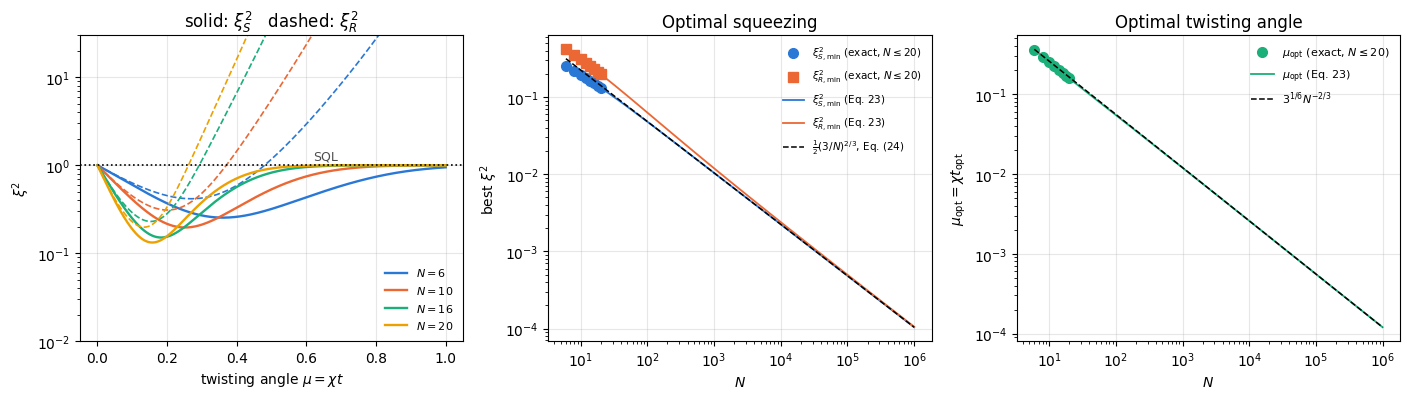

In [11]:
# ==============================================================================
# FIGURE: squeezing versus twisting angle, and the N-scaling of the optimum
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.1))

mu_plot = np.linspace(1e-4, 1.0, 900)
for k, N in enumerate((6, 10, 16, 20)):
    a = oat_analytic(N, mu_plot)
    axes[0].semilogy(mu_plot, a["xi_S2"], "-", color=PALETTE[k], lw=1.7, label=f"$N={N}$")
    axes[0].semilogy(mu_plot, np.clip(a["xi_R2"], 1e-3, 1e2), "--", color=PALETTE[k], lw=1.2)
axes[0].axhline(1.0, color="k", ls=":", lw=1.2)
axes[0].text(0.62, 1.15, "SQL", fontsize=9, color="0.3")
axes[0].set_xlabel(r"twisting angle $\mu=\chi t$"); axes[0].set_ylabel(r"$\xi^2$")
axes[0].set_ylim(1e-2, 30)
axes[0].set_title(r"solid: $\xi_S^2$   dashed: $\xi_R^2$")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].loglog(Ns, [r[2] for r in rows_scan], "o", color=PALETTE[0], ms=7, label=r"$\xi_{S,\min}^2$ (exact, $N\leq20$)")
axes[1].loglog(Ns, [r[4] for r in rows_scan], "s", color=PALETTE[1], ms=7, label=r"$\xi_{R,\min}^2$ (exact, $N\leq20$)")
axes[1].loglog(big[:, 0], big[:, 2], "-", color=PALETTE[0], lw=1.3, label=r"$\xi_{S,\min}^2$ (Eq. 23)")
axes[1].loglog(big[:, 0], big[:, 4], "-", color=PALETTE[1], lw=1.3, label=r"$\xi_{R,\min}^2$ (Eq. 23)")
axes[1].loglog(big[:, 0], 0.5 * (3 / big[:, 0]) ** (2 / 3), "k--", lw=1.1,
               label=r"$\frac{1}{2}(3/N)^{2/3}$, Eq. (24)")
axes[1].set_xlabel("$N$"); axes[1].set_ylabel(r"best $\xi^2$")
axes[1].set_title("Optimal squeezing"); axes[1].legend(fontsize=7.5)

axes[2].loglog(Ns, [r[1] for r in rows_scan], "o", color=PALETTE[2], ms=7, label=r"$\mu_{\rm opt}$ (exact, $N\leq20$)")
axes[2].loglog(big[:, 0], big[:, 1], "-", color=PALETTE[2], lw=1.3, label=r"$\mu_{\rm opt}$ (Eq. 23)")
axes[2].loglog(big[:, 0], 3 ** (1 / 6) * big[:, 0] ** (-2 / 3), "k--", lw=1.1, label=r"$3^{1/6}N^{-2/3}$")
axes[2].set_xlabel("$N$"); axes[2].set_ylabel(r"$\mu_{\rm opt}=\chi t_{\rm opt}$")
axes[2].set_title("Optimal twisting angle"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

The left panel shows the mechanism of Section 5 at work. $\xi_S^2$ (solid) dips sharply, reaches its minimum at a
twisting angle that moves to the left as $N$ grows, and returns to $1$ when the shear has wrapped the distribution
around the sphere. $\xi_R^2$ (dashed) follows it down but turns up earlier and far more violently, because the contrast
$\cos^{N-1}\mu$ in the denominator of Eq. (23) dies like $e^{-N\mu^2/2}$. At $N=20$ the useful window in $\mu$ is
narrower than $0.3$.

The middle and right panels answer the scaling question. The exact simulations ($N\le20$, symbols) lie on the
closed-form curves, and those curves bend onto the asymptotic $N^{-2/3}$ dashed lines only slowly. The local slopes of
Step 7(b) show how slowly. For $\xi^2_{S,\min}$ the local slope is $-0.541$ at $N=10$, $-0.654$ at $N=100$ and
within $10^{-3}$ of $-2/3$ from $N=10^3$ on, where $\xi^2_{S,\min}$ is also within $0.2\%$ of Eq. (24). The range
fits of Step 7(a) average these drifting slopes; reading the fit over $6\le N\le20$ ($-0.54$) as the exponent would be
off by $0.13$. The Wineland parameter follows Eq. (24a): its local slope overshoots to $-0.728$ at
$N=100$ and returns towards $-2/3$ from below ($-0.6768$ at $N=10^5$, against $-0.6767$ from Eq. (24a)), and the ratio
$\xi^2_{R,\min}/\xi^2_{S,\min}$ tracks $1+(3/N)^{1/3}$ to better than $0.5\%$ from $N=10^3$ on. Both parameters share
the asymptotic power and the prefactor; $\xi_R^2$ stays above $\xi_S^2$ at every finite $N$, by a margin that decays
only as $N^{-1/3}$. A fit that reported $\xi_R^2\propto N^{-0.68}$ from data around $N=10^5$ would therefore be measuring
this correction, with no new exponent behind it.

> **Numerical practice.** "Measure the exponent" is a loaded instruction whenever the accessible range spans less than a
> decade. The defensible procedure is the one used here: fit what you can simulate and state the fitted numbers, then
> extend the range with an *independently validated* closed form, and look at local slopes and at the leading
> correction to the asymptotic law rather than at one straight-line fit.

## 11. Squeezing as a Ramsey resource: the full interferometer

The squeezing parameter was *defined* by Eq. (12) as the ratio of phase uncertainties. We now simulate the experiment
that the definition describes.

### 11.1 The protocol

$$\vert+x\rangle^{\otimes N}
\;\xrightarrow[\text{twist}]{\;e^{-i\mu_{\rm opt}J_z^2}\;}\;
\;\xrightarrow[\text{align}]{\;e^{+i\alpha J_x}\;}\;
\;\xrightarrow[\text{encode}]{\;e^{-i\phi J_z}\;}\;
\;\xrightarrow[\text{read out}]{\;e^{-i\frac{\pi}{2}J_x}\;}\;
\text{measure every qubit along }z .$$

Step by step.

1. **Twist** at the optimal angle found in Section 10.
2. **Align.** The minimal-variance quadrature of the twisted state lies at some angle $\alpha$ from $\hat y$ inside the
   $y$–$z$ plane (this is the `alpha` returned by `squeezing_data`). A rotation about the mean-spin axis $\hat x$ by
   $-\alpha$ brings it onto $\hat y$ without touching the mean spin. In the engine's convention this is
   `collective_rotation(psi, -alpha, "x")`, i.e. $e^{+i\alpha J_x}$.
3. **Encode** the unknown phase, $e^{-i\phi J_z}$, which rotates the mean spin from $\hat x$ towards $\hat y$.
4. **Read out.** A $\pi/2$ pulse about $\hat x$ maps the $y$ component onto the $z$ component
   ($(J_y,J_z)\mapsto(-J_z,J_y)$ for the *state*), so that the quantity of interest becomes the population imbalance,
   which is what an experiment counts.
5. **Measure** all $N$ qubits in the computational basis and record $m=\tfrac12(N-2k)$, $k$ = number of ones.

The only outcome that matters is $m$, because the state is permutation symmetric; we therefore histogram the sampled
bit strings into the $N+1$ values of $m$ and work with the distribution $p(m\vert\phi)$.

> **Numerical practice.** Drawing a full bit string per shot and then throwing away everything but $k$ is what the
> experiment does, and the code below does it once, explicitly, and checks that the histogram of $20\,000$ sampled
> strings matches the exact $p(m\vert\phi)$. For the $24\,000$ *repeated* experiments that follow we sample $k$ directly
> from that distribution instead: it is the same random variable, and it avoids an intermediate array of
> $800\times2000\times2^{10}$ Gumbel variates (about $13$ GB) that the batched categorical sampler would otherwise
> allocate. Reducing the sampled object to the statistic you use is often the difference between a program
> that runs and one that does not.

### 11.2 Three predictions under test

* **Error propagation, Eq. (11):** $\Delta\phi=\sqrt{\mathrm{Var}(J_z^{\rm out})}/\vert\partial_\phi\langle J_z^{\rm out}\rangle\vert$
  should equal $\xi_R/\sqrt N$ for the squeezed input and $1/\sqrt N$ for the CSS.
* **The estimator:** a maximum-likelihood estimate of $\phi$ from $M$ sampled shots should have
  $\Delta\hat\phi\approx1/\sqrt{M\,I(\phi)}$ with $I$ the classical Fisher information of $p(m\vert\phi)$, and
  $I\ge N$ for the squeezed input.
* **The bias of the estimator.** Maximum likelihood is biased at finite $M$; to first order in $1/M$ the bias is
  $b_1(\phi)/M$ with $b_1=-\sum_m p'p''/p\,\big/\,(2I^2)$, derived in
  [30](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb), Eq. (14a).
  At the working point $\phi=0$ this bias vanishes *exactly*, for a reason of symmetry. Both input states are invariant
  under the rotation $R=e^{-i\pi J_x}$ (the twisted state because $R$ maps $J_z\to-J_z$ and leaves $J_z^2$ and
  $\vert+x\rangle^{\otimes N}$ unchanged, the alignment and readout pulses because they commute with $R$), while
  $Re^{-i\phi J_z}R^\dagger=e^{+i\phi J_z}$ and the measured $J_z$ changes sign. Hence $p(m\vert\phi)=p(-m\vert-\phi)$:
  on a symmetric search grid the estimator's distribution at $\phi=0$ is symmetric about $0$, whatever $M$. A bias
  measured at $\phi=0$ therefore tests only the sampler. To see the bias we must also run the experiment at a phase
  where it is not zero by symmetry.

In [12]:
# ==============================================================================
# STEP 8: the squeezed Ramsey interferometer, exactly
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_RAM   = 10                     # qubits in the interferometer
PHI_TRUE = 0.0                   # working point: the steepest part of the fringe
# -----------------------------------------------------------------------------
_POP = jnp.asarray(np.array([bin(i).count("1") for i in range(2 ** N_RAM)]))   # popcount of every basis index
_MVALS = N_RAM / 2 - np.arange(N_RAM + 1)                                       # the N+1 values of J_z, descending


def m_distribution(psi):
    """Probability of each value of J_z = (N - 2k)/2 from a state tensor.

    MATH   p(m) = sum_{s : popcount(s) = k} |psi[s]|^2,   m = (N-2k)/2
    JAX    `.at[idx].add(...)` is the functional scatter-add: one pass over the 2^N amplitudes,
           accumulating into N+1 bins indexed by the (precomputed, static) popcount table.
    """
    return jnp.zeros(psi.ndim + 1).at[_POP].add(jnp.abs(psi.reshape(-1)) ** 2)


def ramsey_readout(psi_in, phi):
    """Encode the phase and rotate the measured quadrature onto z; return p(m|phi).

    MATH   |psi_phi> = exp(-i (pi/2) J_x) exp(-i phi J_z) |psi_in>
           so that <J_z>_out = <J_y> after the encoding -- the interferometric signal.
    """
    psi = collective_rotation(psi_in, phi, "z")       # encode
    psi = collective_rotation(psi, jnp.pi / 2, "x")   # y -> z, so that J_z is the signal
    return m_distribution(psi)


# --- build the two input states ---------------------------------------------------------
mu_grid = np.linspace(1e-4, 0.8, 4001)
mu_opt_ram = float(mu_grid[np.argmin(oat_analytic(N_RAM, mu_grid)["xi_R2"])])
psi_twist = oat_evolve(product_state("+" * N_RAM), mu_opt_ram)
d_ram = squeezing_data(psi_twist)
alpha_ram = float(d_ram["alpha"])
INPUTS = {"coherent spin state": product_state("+" * N_RAM),
          "squeezed": collective_rotation(psi_twist, -alpha_ram, "x")}

print(f"N = {N_RAM}:  mu_opt = {mu_opt_ram:.5f},  alignment angle alpha = {alpha_ram:+.5f} rad")
print(f"             xi_R^2 = {float(d_ram['xi_R2']):.5f}  ->  xi_R = {float(jnp.sqrt(d_ram['xi_R2'])):.5f}\n")

# --- CHECKPOINT: after the alignment rotation, Var(J_y) must equal V_min ----------------
d_aligned = squeezing_data(INPUTS["squeezed"])
_, cov_aligned = spin_moments(INPUTS["squeezed"])
print(f"alignment check:  Var(J_y) after rotation = {float(cov_aligned[1, 1]):.8f}"
      f"   V_min of the twisted state = {float(d_ram['V_min']):.8f}")
assert abs(float(cov_aligned[1, 1]) - float(d_ram["V_min"])) < 1e4 * TOL

# --- error propagation, Eq. (11), from the exact output distribution --------------------
print(f"\n{'input':>22s} | {'<J_z>out slope':>15s} {'sqrt Var(J_z)out':>17s} {'Delta phi':>11s} "
      f"{'prediction':>12s} {'I(phi)':>9s}")
eps = 1e-5
exact_rows = {}
for name, pin in INPUTS.items():
    p0 = np.array(ramsey_readout(pin, PHI_TRUE))
    mean_m = float(p0 @ _MVALS)
    var_m = float(p0 @ _MVALS ** 2) - mean_m ** 2
    slope = float((np.array(ramsey_readout(pin, PHI_TRUE + eps)) @ _MVALS
                   - np.array(ramsey_readout(pin, PHI_TRUE - eps)) @ _MVALS) / (2 * eps))
    dphi = np.sqrt(var_m) / abs(slope)
    dp = np.array(jax.jacfwd(lambda t: ramsey_readout(pin, t))(PHI_TRUE))
    ok = p0 > 1e-14
    I_phi = float(np.sum(np.where(ok, dp ** 2 / np.where(ok, p0, 1.0), 0.0)))
    pred = 1 / np.sqrt(N_RAM) if "coherent" in name else float(jnp.sqrt(d_ram["xi_R2"] / N_RAM))
    exact_rows[name] = (I_phi, dphi)
    print(f"{name:>22s} | {slope:15.6f} {np.sqrt(var_m):17.6f} {dphi:11.6f} {pred:12.6f} {I_phi:9.4f}")
    assert abs(dphi - pred) < 1e-6

print(f"\nSQL Fisher information: I = N = {N_RAM};   N/xi_R^2 = {N_RAM / float(d_ram['xi_R2']):.4f};"
      f"   F_Q of the squeezed state = {float(jnp.linalg.eigvalsh(4 * d_ram['cov'])[-1]):.4f}")

N = 10:  mu_opt = 0.20047,  alignment angle alpha = -1.09540 rad
             xi_R^2 = 0.30986  ->  xi_R = 0.55665

alignment check:  Var(J_y) after rotation = 0.53820897   V_min of the twisted state = 0.53820897

                 input |  <J_z>out slope  sqrt Var(J_z)out   Delta phi   prediction    I(phi)


   coherent spin state |        5.000000          1.581139    0.316228     0.316228   10.0000
              squeezed |        4.167671          0.733627    0.176028     0.176028   38.9843

SQL Fisher information: I = N = 10;   N/xi_R^2 = 32.2727;   F_Q of the squeezed state = 39.6132


The error-propagation prediction is met exactly: the coherent input gives $\Delta\phi=0.31623=1/\sqrt{10}$ and the
squeezed input gives $\Delta\phi=0.17603=\xi_R/\sqrt{10}$ with $\xi_R=0.5566$, a factor $1.80$ better. The alignment
rotation works: after it, $\mathrm{Var}(J_y)$ equals the minimal transverse variance $V_{\min}$ to machine precision.

The last column is more interesting than the definition predicts. The classical Fisher information of the *whole*
output distribution $p(m\vert\phi)$ is $I=38.98$ for the squeezed input, while $N/\xi_R^2=32.27$. The error-propagation
formula only uses the mean and the variance of the distribution; an estimator that uses the entire histogram can do
better, and it does — by $21\%$ in Fisher information, i.e. a further $10\%$ in $\Delta\phi$. Both numbers stay below
the quantum Fisher information $F_Q=39.61$ of that state, as the Braunstein–Caves theorem
([29](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb)) requires. We now check that a real
estimator, fed real samples, reaches $1/\sqrt{MI}$.

In [13]:
# ==============================================================================
# STEP 9: simulated shots and maximum-likelihood phase estimation
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
M_SHOTS  = (25, 50, 100, 200, 400, 800)    # shots per experiment
R_EXP    = 2000                             # independent experiments per point (variance + its error bar)
PHI_GRID = jnp.linspace(-0.45, 0.45, 601)   # maximum-likelihood search window (well inside one fringe)
# -----------------------------------------------------------------------------


def out_state(psi_in, phi):
    """The state the detector actually sees: encode the phase, then rotate the y quadrature onto z."""
    return collective_rotation(collective_rotation(psi_in, phi, "z"), jnp.pi / 2, "x")


# --- what one shot looks like ------------------------------------------------------------
psi_out_sq = out_state(INPUTS["squeezed"], PHI_TRUE)
bits_demo = np.array(sample_bitstrings(jax.random.PRNGKey(7), psi_out_sq, 8))
print("eight shots of the squeezed interferometer (one row = a projective measurement of all N qubits):")
for b in bits_demo:
    k = int(b.sum())
    print("   " + "".join(str(int(x)) for x in b) + f"    k = {k:2d}    J_z = {N_RAM / 2 - k:+5.1f}")

# --- CHECKPOINT: sampled bit strings reproduce the exact distribution p(m|phi) -------------
N_DEMO_SHOTS = 20_000
k_sample = np.array(sample_bitstrings(jax.random.PRNGKey(8), psi_out_sq, N_DEMO_SHOTS)).sum(axis=1)
freq = np.bincount(k_sample, minlength=N_RAM + 1) / N_DEMO_SHOTS
exact_p = np.array(ramsey_readout(INPUTS["squeezed"], PHI_TRUE))
counts_demo = np.bincount(k_sample, minlength=N_RAM + 1)


def chi2_dof(counts, p):
    """Pearson chi^2 per degree of freedom of a histogram against probabilities p, over bins with n p >= 5."""
    n, keep = counts.sum(), counts.sum() * p >= 5
    return float(np.sum((counts[keep] - n * p[keep]) ** 2 / (n * p[keep]))) / (int(keep.sum()) - 1), int(keep.sum()) - 1


chi2_ok, dof_ok = chi2_dof(counts_demo, exact_p)
# wrong control: the same histogram tested against the twisted state WITHOUT the alignment rotation
p_wrong = np.array(ramsey_readout(psi_twist, PHI_TRUE))
chi2_bad, dof_bad = chi2_dof(counts_demo, p_wrong)
print(f"\n{N_DEMO_SHOTS} sampled bit strings vs the exact p(m|phi):"
      f"  max deviation {np.max(np.abs(freq - exact_p)):.2e}"
      f"   (expected statistical size {0.5 / np.sqrt(N_DEMO_SHOTS):.2e})")
print(f"   chi^2/dof = {chi2_ok:.3f} over {dof_ok} dof   (1 +- {np.sqrt(2 / dof_ok):.2f} expected)")
print(f"   wrong control, p(m|phi) of the un-aligned twisted state: chi^2/dof = {chi2_bad:.1f}")
assert abs(chi2_ok - 1) < 5 * np.sqrt(2 / dof_ok) and chi2_bad > 1 + 20 * np.sqrt(2 / dof_bad)


def ml_experiments(key, logp_grid, p_true, shots, n_exp):
    """`n_exp` independent experiments of `shots` shots each; return the maximum-likelihood estimates.

    PROTOCOL  one shot = measure all N qubits and record k = number of ones, i.e. J_z = (N-2k)/2.
        The cell above draws the bit strings explicitly with `sample_bitstrings` and checks that their
        histogram reproduces p(m|phi).  Here we sample the REDUCED outcome k directly from that same
        distribution: statistically identical, but it avoids materialising the 2^N Gumbel variates that
        `jax.random.categorical` would need for every one of the `shots` x `n_exp` bit strings
        (at 800 shots x 2000 experiments x 2^10 amplitudes that intermediate array alone is ~13 GB).
    MATH   log L(phi) = sum_m n_m log p(m|phi)  ->  ONE matrix-vector product logp_grid @ counts,
        evaluated on the whole phi grid at once; the estimate is the arg max.
    JAX    `vmap` over PRNG keys runs all `n_exp` experiments as a single batched program. `shots` and
        `n_exp` fix array shapes, so they are static: one compilation per (shots, n_exp) pair, shared by
        both input states (the probability tables are traced arguments of the same shape).
    """
    lp = jnp.log(p_true)

    def one(k):
        idx = jax.random.categorical(k, lp, shape=(shots,))
        counts = jnp.bincount(idx, length=p_true.shape[0])
        return PHI_GRID[jnp.argmax(logp_grid @ counts)]

    return jax.vmap(one)(jax.random.split(key, n_exp))


ml_jit = jax.jit(ml_experiments, static_argnames=("shots", "n_exp"))
KEY_ML = jax.random.PRNGKey(2025)
compiled_ml, results_ml, t_compile, t_run = {}, {}, 0.0, 0.0
for i_in, (name, pin) in enumerate(INPUTS.items()):
    logp = jnp.log(jnp.clip(jax.vmap(lambda t: ramsey_readout(pin, t))(PHI_GRID), 1e-300, None))
    p_true = jnp.clip(ramsey_readout(pin, PHI_TRUE), 1e-300, None)
    rows = []
    for j, M in enumerate(M_SHOTS):
        key = jax.random.fold_in(KEY_ML, 100 * i_in + j)        # an independent key for every row of both tables
        if M not in compiled_ml:                                # ahead-of-time compilation, timed apart from the run
            t0 = time.time()
            compiled_ml[M] = ml_jit.lower(key, logp, p_true, shots=M, n_exp=R_EXP).compile()
            t_compile += time.time() - t0
        t0 = time.time()
        est = compiled_ml[M](key, logp, p_true).block_until_ready()   # the executable takes the traced arguments
        t_run += time.time() - t0
        var = float(jnp.var(est))
        se_bias = float(jnp.std(est)) / np.sqrt(R_EXP)
        rows.append((M, float(jnp.mean(est)) - PHI_TRUE, var, var * np.sqrt(2 / (R_EXP - 1)), se_bias))
    results_ml[name] = rows
print(f"\n(simulated {2 * len(M_SHOTS) * R_EXP} experiments: compilation of the {len(M_SHOTS)} shapes {t_compile:.1f} s, "
      f"execution {t_run:.1f} s)\n")

for name, rows in results_ml.items():
    I_phi = exact_rows[name][0]
    print(f"{name}   (classical Fisher information I = {I_phi:.4f})")
    print(f"   {'M':>6s} {'bias +- se':>20s} {'Delta phi':>11s} {'1/sqrt(M I)':>12s} {'SQL 1/sqrt(NM)':>15s} "
          f"{'ratio to SQL':>13s} {'M I Var +- se':>15s}")
    for M, bias, var, err, se_b in rows:
        print(f"   {M:6d} {bias:+10.5f} +- {se_b:.5f} {np.sqrt(var):11.6f} {1 / np.sqrt(M * I_phi):12.6f} "
              f"{1 / np.sqrt(N_RAM * M):15.6f} {np.sqrt(var) * np.sqrt(N_RAM * M):13.4f} "
              f"{var * M * I_phi:7.3f} +- {err * M * I_phi:.3f}")
    print()
# at phi = 0 the bias is zero by symmetry: every row must be compatible with zero (4 standard errors)
assert all(abs(r[1]) < 4 * r[4] for rows in results_ml.values() for r in rows)
# for M >= 200 the estimator is efficient within 4 error bars
assert all(abs(r[2] * r[0] * exact_rows[nm][0] - 1) < 4 * r[3] * r[0] * exact_rows[nm][0]
           for nm, rows in results_ml.items() for r in rows if r[0] >= 200)

eight shots of the squeezed interferometer (one row = a projective measurement of all N qubits):
   1010100110    k =  5    J_z =  +0.0
   1101011000    k =  5    J_z =  +0.0
   1101101100    k =  6    J_z =  -1.0
   1001001100    k =  4    J_z =  +1.0
   0011001101    k =  5    J_z =  +0.0
   1000100111    k =  5    J_z =  +0.0
   1001010001    k =  4    J_z =  +1.0
   0001010011    k =  4    J_z =  +1.0



20000 sampled bit strings vs the exact p(m|phi):  max deviation 7.95e-03   (expected statistical size 3.54e-03)
   chi^2/dof = 2.062 over 6 dof   (1 +- 0.58 expected)
   wrong control, p(m|phi) of the un-aligned twisted state: chi^2/dof = 5254.0



(simulated 24000 experiments: compilation of the 6 shapes 10.5 s, execution 1.0 s)

coherent spin state   (classical Fisher information I = 10.0000)
        M           bias +- se   Delta phi  1/sqrt(M I)  SQL 1/sqrt(NM)  ratio to SQL   M I Var +- se
       25   -0.00101 +- 0.00140    0.062493     0.063246        0.063246        0.9881   0.976 +- 0.031
       50   +0.00051 +- 0.00100    0.044778     0.044721        0.044721        1.0013   1.003 +- 0.032
      100   -0.00021 +- 0.00073    0.032702     0.031623        0.031623        1.0341   1.069 +- 0.034
      200   +0.00038 +- 0.00050    0.022453     0.022361        0.022361        1.0041   1.008 +- 0.032
      400   +0.00060 +- 0.00036    0.016034     0.015811        0.015811        1.0141   1.028 +- 0.033
      800   -0.00023 +- 0.00026    0.011501     0.011180        0.011180        1.0286   1.058 +- 0.033

squeezed   (classical Fisher information I = 38.9843)
        M           bias +- se   Delta phi  1/sqrt(M I)  SQL 1/sqrt(N

In [14]:
# ==============================================================================
# STEP 9b: the bias of the estimator, measured where it is not zero by symmetry
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
PHI_B  = 0.2                       # working point away from the symmetric phi = 0 (on the search grid)
M_B    = (25, 50, 100)             # shots per experiment
R_B    = 40_000                    # experiments per row: the bias is ~1e-3, its standard error must be ~1e-4
# -----------------------------------------------------------------------------


def first_order_bias(pin, phi):
    """b_1(phi) of nb 30, Eq. (14a): E[phi_hat] - phi = b_1/M + O(1/M^2), and the Fisher information I(phi).

    MATH   b_1 = -(1/(2 I^2)) sum_m p'_m p''_m / p_m,   I = sum_m p'_m^2 / p_m   (derivatives in phi)
    JAX    p' and p'' by forward-mode differentiation of the exact readout distribution (no finite differences).
    """
    f = lambda t: ramsey_readout(pin, t)
    p0, d1, d2 = np.array(f(phi)), np.array(jax.jacfwd(f)(phi)), np.array(jax.jacfwd(jax.jacfwd(f))(phi))
    ok = p0 > 1e-14
    I = float(np.sum(d1[ok] ** 2 / p0[ok]))
    return -float(np.sum(d1[ok] * d2[ok] / p0[ok])) / (2 * I ** 2), I


pin_b = INPUTS["squeezed"]
logp_b = jnp.log(jnp.clip(jax.vmap(lambda t: ramsey_readout(pin_b, t))(PHI_GRID), 1e-300, None))
p_b = jnp.clip(ramsey_readout(pin_b, PHI_B), 1e-300, None)
b1, I_b = first_order_bias(pin_b, PHI_B)
b1_zero, _ = first_order_bias(pin_b, 0.0)
print(f"squeezed input, N = {N_RAM}:  b_1(phi = {PHI_B}) = {b1:+.5f},  I(phi = {PHI_B}) = {I_b:.4f};"
      f"   b_1(phi = 0) = {b1_zero:+.1e} (zero by symmetry)\n")
print(f"{'M':>5s} | {'bias +- se':>22s} {'b_1/M (Eq. 14a of nb 30)':>25s} {'z vs b_1/M':>11s} {'z vs 0':>8s} | "
      f"{'M I Var +- se':>16s}")
bias_rows = []
for j, M in enumerate(M_B):
    est = jax.jit(ml_experiments, static_argnames=("shots", "n_exp"))(
        jax.random.fold_in(jax.random.PRNGKey(31), j), logp_b, p_b, shots=M, n_exp=R_B)
    bias, se = float(jnp.mean(est)) - PHI_B, float(jnp.std(est)) / np.sqrt(R_B)
    eff = float(jnp.var(est)) * M * I_b
    bias_rows.append((M, bias, se, (bias - b1 / M) / se, bias / se))
    print(f"{M:5d} | {bias:+11.5f} +- {se:.5f} {b1 / M:25.5f} {(bias - b1 / M) / se:+11.2f} {bias / se:+8.1f} | "
          f"{eff:7.4f} +- {eff * np.sqrt(2 / (R_B - 1)):.4f}")
assert abs(b1_zero) < 1e-8
assert abs(bias_rows[-1][3]) < 4                      # at M = 100 the first-order bias b_1/M describes the data
assert bias_rows[0][3] > bias_rows[-1][3]             # the O(1/M^2) excess is largest at the smallest M
assert max(abs(r[4]) for r in bias_rows) > 5          # wrong control: "unbiased" is rejected

squeezed input, N = 10:  b_1(phi = 0.2) = +0.05608,  I(phi = 0.2) = 38.5164;   b_1(phi = 0) = -2.8e-17 (zero by symmetry)

    M |             bias +- se  b_1/M (Eq. 14a of nb 30)  z vs b_1/M   z vs 0 |    M I Var +- se


   25 |    +0.00306 +- 0.00017                   0.00224       +4.70    +17.6 |  1.1593 +- 0.0082


   50 |    +0.00152 +- 0.00012                   0.00112       +3.32    +12.7 |  1.1011 +- 0.0078


  100 |    +0.00061 +- 0.00008                   0.00056       +0.54     +7.4 |  1.0341 +- 0.0073


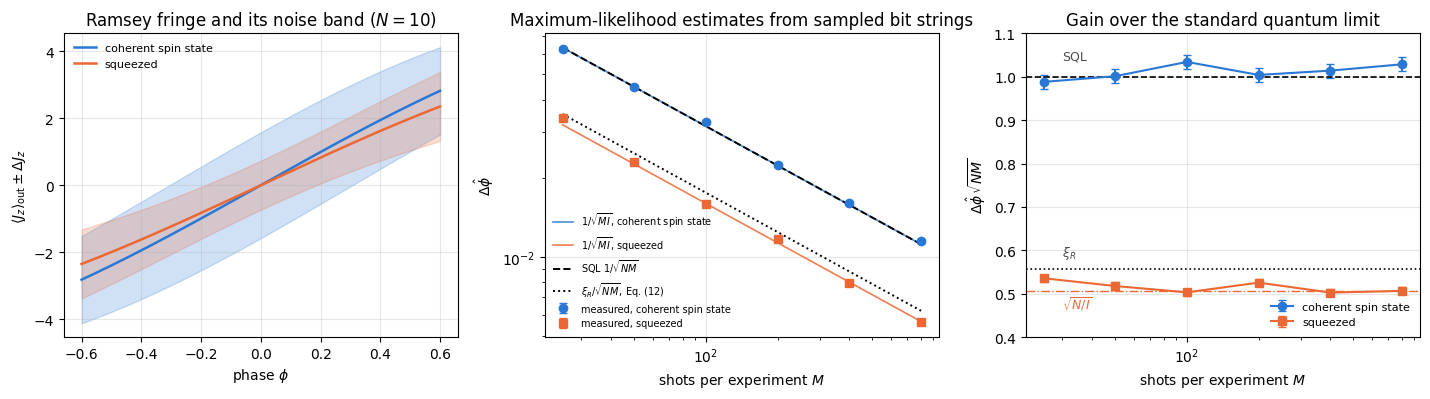

In [15]:
# ==============================================================================
# FIGURE: the squeezed interferometer beats the standard quantum limit
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.1))

phis = np.linspace(-0.6, 0.6, 241)
for k, (name, pin) in enumerate(INPUTS.items()):
    sig = np.array([np.array(ramsey_readout(pin, float(p))) @ _MVALS for p in phis])
    var = np.array([np.array(ramsey_readout(pin, float(p))) @ _MVALS ** 2 for p in phis]) - sig ** 2
    axes[0].plot(phis, sig, "-", color=PALETTE[k], lw=1.8, label=name)
    axes[0].fill_between(phis, sig - np.sqrt(var), sig + np.sqrt(var), color=PALETTE[k], alpha=0.22)
axes[0].set_xlabel(r"phase $\phi$"); axes[0].set_ylabel(r"$\langle J_z\rangle_{\rm out}\pm\Delta J_z$")
axes[0].set_title(f"Ramsey fringe and its noise band ($N={N_RAM}$)"); axes[0].legend(fontsize=8)

Ms = np.array(M_SHOTS, dtype=float)
for k, (name, rows) in enumerate(results_ml.items()):
    v = np.array([r[2] for r in rows]); e = np.array([r[3] for r in rows])
    I_phi = exact_rows[name][0]
    axes[1].errorbar(Ms, np.sqrt(v), yerr=0.5 * e / np.sqrt(v), fmt=MARKERS[k], color=PALETTE[k], ms=6,
                     capsize=3, label=f"measured, {name}")
    axes[1].plot(Ms, 1 / np.sqrt(Ms * I_phi), "-", color=PALETTE[k], lw=1.2, alpha=0.85,
                 label=r"$1/\sqrt{M I}$, " + name)
axes[1].plot(Ms, 1 / np.sqrt(N_RAM * Ms), "k--", lw=1.4, label=r"SQL $1/\sqrt{NM}$")
axes[1].plot(Ms, float(jnp.sqrt(d_ram["xi_R2"])) / np.sqrt(N_RAM * Ms), "k:", lw=1.4,
             label=r"$\xi_R/\sqrt{NM}$, Eq. (12)")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("shots per experiment $M$"); axes[1].set_ylabel(r"$\Delta\hat\phi$")
axes[1].set_title("Maximum-likelihood estimates from sampled bit strings"); axes[1].legend(fontsize=7)

for k, (name, rows) in enumerate(results_ml.items()):
    v = np.array([r[2] for r in rows]); e = np.array([r[3] for r in rows])
    axes[2].errorbar(Ms, np.sqrt(v * N_RAM * Ms), yerr=0.5 * e / np.sqrt(v) * np.sqrt(N_RAM * Ms),
                     fmt=MARKERS[k] + "-", color=PALETTE[k], ms=6, capsize=3, label=name)
axes[2].axhline(1.0, color="k", ls="--", lw=1.2)
axes[2].axhline(float(jnp.sqrt(d_ram["xi_R2"])), color="k", ls=":", lw=1.2)
axes[2].text(30, 1.04, "SQL", fontsize=9, color="0.3")
axes[2].text(30, float(jnp.sqrt(d_ram["xi_R2"])) + 0.03, r"$\xi_R$", fontsize=9, color="0.3")
axes[2].axhline(np.sqrt(N_RAM / exact_rows["squeezed"][0]), color=PALETTE[1], ls="-.", lw=1.0)
axes[2].text(30, np.sqrt(N_RAM / exact_rows["squeezed"][0]) - 0.04, r"$\sqrt{N/I}$", fontsize=9, color=PALETTE[1])
axes[2].set_ylim(0.4, 1.1)
axes[2].set_xscale("log"); axes[2].set_xlabel("shots per experiment $M$")
axes[2].set_ylabel(r"$\Delta\hat\phi\,\sqrt{NM}$")
axes[2].set_title("Gain over the standard quantum limit"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

The eight printed shots are what the apparatus records: eight strings of ten bits, from which only the number
of ones is kept. Their histogram over $20\,000$ shots reproduces the exact $p(m\vert\phi)$ with a largest deviation of
$8.0\times10^{-3}$, about twice the largest per-bin standard deviation $1/(2\sqrt{20000})=3.5\times10^{-3}$, and
$\chi^2/\mathrm{dof}=2.06$ over $6$ degrees of freedom ($1.8$ standard deviations above $1$). The wrong control, the
same histogram tested against the twisted state without the alignment rotation, gives $\chi^2/\mathrm{dof}=5254$: the
test resolves the alignment step.

The left panel shows what squeezing buys. Both fringes have almost the same shape; what differs is the width of the
noise band at the steep point $\phi=0$, and the slope. The squeezed state has a smaller slope (the contrast
loss, $\vert\langle\mathbf J\rangle\vert=4.17$ against $5$) and a much smaller noise band ($\sqrt{V_{\min}}=0.73$
against $1.58$); the ratio of the two effects is $\xi_R$.

The middle and right panels compare the estimator with its bounds. Every row of the two tables uses its own PRNG key,
so the rows are statistically independent. For both inputs the measured $\Delta\hat\phi$ falls like $1/\sqrt M$ and
sits on its own classical bound $1/\sqrt{MI}$: the scaled quantity $M\,I\,\mathrm{Var}(\hat\phi)$ ranges over
$0.976$–$1.069$ for the coherent input and $0.985$–$1.119$ for the squeezed one, against a $3.2\%$ statistical error bar
on a variance measured from $2000$ experiments. The largest excursion is the squeezed $M=25$ point, $1.119\pm0.035$,
where the estimator is not yet asymptotic; Step 9b measures the same finite-$M$ excess with much smaller error bars
($1.159\pm0.008$ at $M=25$, $1.034\pm0.007$ at $M=100$). The right panel plots the gain directly: the coherent-state
curve sits on $1$ within about two error bars, and the squeezed curve sits at $0.50$–$0.54$, around the value
$\sqrt{N/I}=0.507$ predicted by the classical Fisher information and **below the $\xi_R=0.557$ line**, because the
maximum-likelihood estimator exploits the whole histogram rather than its mean alone.

The bias at $\phi=0$ is compatible with zero in all twelve rows (largest deviation $1.7$ standard errors), as the
symmetry argument of Section 11.2 requires; this tests the sampler and nothing else. At $\phi=0.2$, Step 9b resolves
the bias: $+0.00061\pm0.00008$ at $M=100$, against $b_1/M=0.00056$ from Eq. (14a) of notebook 30, and the hypothesis
"unbiased" is rejected by $7$ to $18$ standard errors. At $M=25$ and $M=50$ the measured bias exceeds $b_1/M$ by
$4.7$ and $3.3$ standard errors. The excess shrinks with $M$ ($0.00082$, $0.00040$ and $0.00005$ at $M=25$, $50$,
$100$), as the higher-order terms of the $1/M$ expansion must. The bias is of order $10^{-3}$ against a standard deviation of order $10^{-2}$, so it is negligible in the mean
squared error at these $M$.

In clock terms, $I=38.98$ against $I=10$ means the squeezed interferometer reaches a given phase uncertainty with
$3.9$ times fewer interrogations.

Execution of the compiled estimator is fast: the $24\,000$ simulated experiments of Step 9 run in about $1$ s, while
compiling the six array shapes (one per $M$; the two inputs share them) takes about ten times longer. Steps 6 and 11
print the same split.

> **Physics insight.** The protocol uses only standard ingredients: the twisting is an interaction the atoms have
> anyway, the alignment and readout pulses are collective rotations, and the measurement is the population counting that
> every Ramsey interferometer already performs. These are the ingredients of the 2010 squeezing experiments cited in
> Section 4.3. Under independent dephasing during
> the interrogation, spin-squeezed probes also reach asymptotically the best resolution available to generalised Ramsey
> spectroscopy, a factor $\sqrt e$ better than uncorrelated atoms (Ulam-Orgikh and Kitagawa 2001; the bound and its
> derivation are in [32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb),
> Section 13.2).

## 12. The Husimi-$Q$ distribution on the Bloch sphere

Covariance matrices summarise a distribution by its second moments. Once the state stops being Gaussian-like — and it
does, quickly — we need to see the distribution itself.

### 12.1 Definition

The **Husimi-$Q$ function** of a spin state is its overlap with the coherent spin state pointing in each direction:

$$Q(\theta,\varphi)\;=\;\left\vert\left\langle\theta,\varphi\middle\vert\psi\right\rangle\right\vert^2 , \tag{25}$$

with $\vert\theta,\varphi\rangle$ from Eq. (3). It is non-negative everywhere, it is the closest thing to a classical
probability density on the sphere (it is the distribution of the outcome of an idealised measurement of the spin
direction), and for a CSS it is a bell-shaped bump of angular width $\sim1/\sqrt N$.

### 12.2 From formula to code

$\vert\theta,\varphi\rangle$ is a *product* state, so Eq. (25) is a contraction of the rank-$N$ tensor $\psi$ with the
same $2$-vector $v=(\cos\tfrac{\theta}{2},\,e^{i\varphi}\sin\tfrac{\theta}{2})$ on every axis:

$$\langle\theta,\varphi\vert\psi\rangle=\sum_{s_0\ldots s_{N-1}}\overline{v[s_0]}\cdots\overline{v[s_{N-1}]}\;\psi[s_0,\ldots,s_{N-1}].$$

For $N=3$ the einsum string is `"a,b,c,abc->"` with operands $\bar v,\bar v,\bar v,\psi$. Contracting one axis at a
time costs $2^N+2^{N-1}+\cdots\approx2^{N+1}$ operations, so the whole grid of directions is cheap; we `vmap` the
single-point function over the grid and let XLA batch it.

We draw the sphere in the **equal-area cylindrical projection** $(\varphi,\cos\theta)$: areas on this map are
proportional to areas on the sphere, so a round blob near the equator stays round and relative weights are not
distorted. The
initial CSS sits at $(\varphi,\cos\theta)=(0,0)$.

In [16]:
# ==============================================================================
# STEP 10: the Husimi-Q distribution as one batched contraction
# ==============================================================================
def css_vector(theta, phi):
    """The single-qubit spinor of the coherent spin state pointing at (theta, phi), Eq. (3)."""
    return jnp.stack([jnp.cos(theta / 2), jnp.exp(1j * phi) * jnp.sin(theta / 2)]).astype(CDTYPE)


def css_overlap(psi, theta, phi):
    """<theta,phi|psi> for a product 'probe' state: contract every axis of psi with conj(v)."""
    v = jnp.conj(css_vector(theta, phi))
    out = psi
    for _ in range(psi.ndim):
        out = jnp.tensordot(v, out, axes=([0], [0]))     # always contract the leading axis
    return out


def husimi_q(psi, theta_grid, phi_grid):
    """Q(theta, phi) = |<theta,phi|psi>|^2 on a 2D grid, Eq. (25).

    JAX   nested `vmap` over the two grid axes: one fused program, no Python loop over grid points.
    COST  O(2^{N+1}) per grid point.
    """
    single = lambda th, ph: jnp.abs(css_overlap(psi, th, ph)) ** 2
    return jax.vmap(jax.vmap(single, in_axes=(0, 0)), in_axes=(0, 0))(theta_grid, phi_grid)


# PARAMETERS ------------------------------------------------------------------
N_Q    = 10                     # system size for the Bloch-sphere pictures
N_PHI  = 141                    # grid resolution in azimuth
N_COS  = 71                     # grid resolution in cos(theta)
# -----------------------------------------------------------------------------
phi_ax = np.linspace(-np.pi, np.pi, N_PHI)
cos_ax = np.linspace(-1.0, 1.0, N_COS)
PHI_M, COS_M = np.meshgrid(phi_ax, cos_ax)
THETA_M = np.arccos(np.clip(COS_M, -1.0, 1.0))
psi_q0 = product_state("+" * N_Q)

# --- CHECKPOINT: Q of a CSS peaks at the right place with the right height ---------------
q_css = np.array(husimi_q(psi_q0, jnp.asarray(THETA_M), jnp.asarray(PHI_M)))
iy, ix = np.unravel_index(np.argmax(q_css), q_css.shape)
print(f"Q of |+x>^{N_Q}: maximum {q_css.max():.6f} at (phi, cos theta) = ({phi_ax[ix]:+.4f}, {cos_ax[iy]:+.4f})"
      f"   [expected 1.0 at (0, 0)]")
print(f"   at the antipode (-x):  {q_css[N_COS // 2, 0]:.3e}"
      f"   [|<-x|+x>|^(2N) = 0 exactly]")
print(f"   at the north pole:     {q_css[-1, N_PHI // 2]:.6e}"
      f"   [|<0|+x>|^(2N) = 2^-N = {2.0 ** -N_Q:.6e}]")
assert abs(q_css.max() - 1.0) < 1e-3 and abs(phi_ax[ix]) < 0.05 and abs(cos_ax[iy]) < 0.05
assert abs(q_css[-1, N_PHI // 2] - 2.0 ** -N_Q) < 1e-9

Q of |+x>^10: maximum 1.000000 at (phi, cos theta) = (+0.0000, +0.0000)   [expected 1.0 at (0, 0)]
   at the antipode (-x):  0.000e+00   [|<-x|+x>|^(2N) = 0 exactly]
   at the north pole:     9.765625e-04   [|<0|+x>|^(2N) = 2^-N = 9.765625e-04]


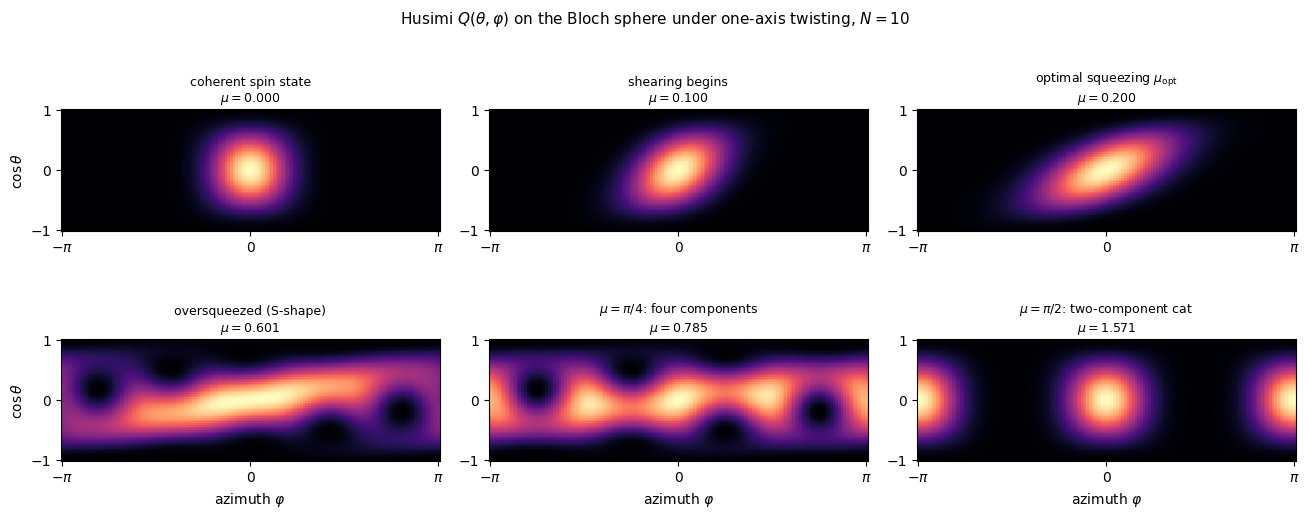

In [17]:
# ==============================================================================
# FIGURE: Husimi-Q at six twisting angles -- disc, ellipse, S-shape, cat
# ==============================================================================
mu_opt_q = float(mu_grid[np.argmin(oat_analytic(N_Q, mu_grid)["xi_R2"])])
MU_PANELS = [(0.0, "coherent spin state"), (0.5 * mu_opt_q, "shearing begins"),
             (mu_opt_q, r"optimal squeezing $\mu_{\rm opt}$"), (3 * mu_opt_q, "oversqueezed (S-shape)"),
             (np.pi / 4, r"$\mu=\pi/4$: four components"), (np.pi / 2, r"$\mu=\pi/2$: two-component cat")]

fig, axes = plt.subplots(2, 3, figsize=(13.2, 5.4))
for ax, (mu, label) in zip(axes.ravel(), MU_PANELS):
    q = np.array(husimi_q(oat_evolve(psi_q0, mu), jnp.asarray(THETA_M), jnp.asarray(PHI_M)))
    ax.pcolormesh(phi_ax, cos_ax, q, shading="auto", cmap="magma", vmin=0.0)
    ax.set_aspect("equal")
    ax.set_title(f"{label}\n" + r"$\mu=" + f"{mu:.3f}$", fontsize=9)
    ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-1, 0, 1])
    ax.grid(False)
for ax in axes[1]:
    ax.set_xlabel(r"azimuth $\varphi$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\cos\theta$")
fig.suptitle(f"Husimi $Q(\\theta,\\varphi)$ on the Bloch sphere under one-axis twisting, $N={N_Q}$", fontsize=11)
fig.tight_layout(); plt.show()

The six panels show the mechanism of Section 5. Each panel carries its own colour scale, running from
$0$ (black) to that panel's own maximum of $Q$ (white): the peak value of $Q$ falls from $1.00$ to $0.27$ between the
first panel and the last, and a common scale would darken the late panels. Compare *shapes* across panels, not
brightnesses.

* $\mu=0$: a round blob at $(\varphi,\cos\theta)=(0,0)$, the coherent spin state. Its angular radius is $1/\sqrt N$ in
  both directions — the isotropy proved in Section 3.3.
* $\mu=\tfrac12\mu_{\rm opt}$ and $\mu=\mu_{\rm opt}$: the blob shears into an ellipse tilted in the $(\varphi,\cos\theta)$
  plane, exactly as Eq. (7) predicts. The short axis is the squeezed quadrature.
* $\mu=3\mu_{\rm opt}=0.601$: the ellipse has stopped being an ellipse. The shear is large enough that the curvature of
  the sphere bends it into a slanted band that wraps all the way around in azimuth, with dark interference holes above
  and below it. The variance in the short direction is no longer small, and $\xi^2$ has turned back up.
* $\mu=\pi/4$: the band has broken into four maxima, still partly overlapping at $N=10$ — a superposition of four
  coherent states, each of angular width $1/\sqrt N$, which is not yet small compared with their separation $\pi/2$.
* $\mu=\pi/2$: exactly two lobes, at $\varphi=0$ and $\varphi=\pi$ (the second one split across the periodic edge of
  the map) — the two poles of the $x$ axis. This is a GHZ-like cat state,
  $\left(\vert+x\rangle^{\otimes N}+e^{i\beta}\vert-x\rangle^{\otimes N}\right)/\sqrt2$ up to phases, and it is the
  subject of the next notebook.

Note what the pictures do *not* show: the coherences. Two lobes of $Q$ are compatible both with a cat state and with a
classical mixture of two coherent states; $Q$ cannot distinguish them. The quantum Fisher information can, and does —
$F_Q=N^2$ for the cat, $F_Q=N$ for the mixture.

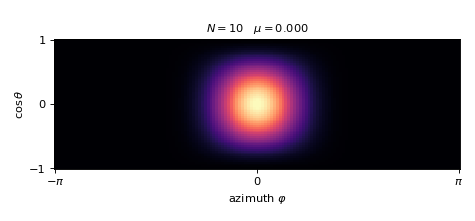

   [48 frames, 1.09 MB embedded in the notebook]


In [18]:
# ==============================================================================
# ANIMATION: the Husimi-Q distribution during the whole twisting evolution
# ==============================================================================
def make_husimi_gif(psi0, mus, theta_grid, phi_grid, phi_ax, cos_ax, title="", fps=10, dpi=82,
                    figsize=(5.8, 2.7)):
    """Animate Q(theta, phi) over a list of twisting angles and embed the result as a GIF.

    IMPLEMENTATION  FuncAnimation -> PillowWriter -> a temporary file -> bytes -> ONE display() carrying
        both an "image/gif" and a base64 "<img>" text/html representation of the same animation
        (Quarto drops bare image/gif outputs, Jupyter and GitHub prefer them -- emitting both works
        everywhere).  The temporary directory removes itself: the notebook writes nothing to disk.
    """
    # each frame is rescaled to its OWN maximum: the peak of Q drops by a factor ~4 during the evolution
    # (1.00 at mu=0 down to 0.26 near mu=0.84), so a common colour scale would darken the middle frames.
    frames = [np.array(husimi_q(oat_evolve(psi0, float(m)), theta_grid, phi_grid)) for m in mus]
    frames = [f / f.max() for f in frames]
    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(phi_ax, cos_ax, frames[0], shading="auto", cmap="magma", vmin=0.0, vmax=1.0)
    ax.set_aspect("equal"); ax.grid(False)
    ax.set_xticks([-np.pi, 0, np.pi]); ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-1, 0, 1])
    ax.set_xlabel(r"azimuth $\varphi$"); ax.set_ylabel(r"$\cos\theta$")
    txt = ax.set_title("", fontsize=10)
    fig.tight_layout()

    def update(i):
        mesh.set_array(frames[i].ravel())
        txt.set_text(f"{title}   $\\mu = {mus[i]:.3f}$")
        return ()

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps, blit=False)
    with tempfile.TemporaryDirectory() as tmpdir:
        path = os.path.join(tmpdir, "anim.gif")
        anim.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        with open(path, "rb") as fh:
            gif_bytes = fh.read()
    plt.close(fig)
    b64 = base64.b64encode(gif_bytes).decode("ascii")
    tag = f'<img src="data:image/gif;base64,{b64}" alt="animation" style="max-width:100%;height:auto">'
    display({"image/gif": b64, "text/html": tag}, raw=True)
    print(f"   [{len(frames)} frames, {len(gif_bytes) / 1e6:.2f} MB embedded in the notebook]")


MU_FRAMES = np.linspace(0.0, np.pi / 2, 48)
make_husimi_gif(psi_q0, MU_FRAMES, jnp.asarray(THETA_M), jnp.asarray(PHI_M), phi_ax, cos_ax,
                title=f"$N={N_Q}$")

The animation runs from $\mu=0$ to $\mu=\pi/2$ in $48$ frames; each frame is rescaled to its own maximum, because the
peak height of $Q$ falls by a factor of about four as the state spreads (from $1.00$ at $\mu=0$ to $0.26$ near
$\mu=0.84$, recovering to $0.50$ at the cat). Watch three things: the blob shears
and tilts within the first few frames (that is where all the useful squeezing happens); it then smears into a band
that wraps the sphere; and near the end it reassembles, sharply, into a small number of lobes — the revivals of a
system with an *integer* energy spectrum $\chi m^2$, which is exactly periodic.

> **Physics insight.** The spectrum of $H=\chi J_z^2$ is $\chi m^2$ with $m$ integer or half-integer, so every
> expectation value is a periodic function of $\mu$. Nothing dephases permanently: what looks like decoherence at
> intermediate times is an ordinary, reversible dephasing among finitely many levels, and it rephases. The cat at
> $\mu=\pi/2$ is the most spectacular of those revivals.

## 13. The limit of squeezing as a measure of metrological gain

The Wineland parameter was derived from the error-propagation formula, Eq. (11), which uses only the first two moments
of one measured observable. The quantum Fisher information uses the whole state. The general relation is

$$F_Q\;\ge\;\frac{N}{\xi_R^2}, \tag{26}$$

which follows from the quantum Cramér–Rao bound: $N/\xi_R^2=\vert\langle\mathbf J\rangle\vert^2/V_{\min}$ is
$1/(\Delta\phi)^2$ for one *particular* readout strategy (rotate, measure one quadrature, invert the mean signal),
while $F_Q$ bounds $1/(\Delta\phi)^2$ for *every* strategy, optimal measurement and optimal estimator included.
A specific strategy can never beat the optimum over all of them, hence Eq. (26).

For the twisted states the gap in Eq. (26) has an exact expression. The state is invariant under $e^{-i\pi J_x}$
(Section 11.2), which flips $J_y$ and $J_z$ and leaves $J_x$ alone, so $C_{xy}=C_{xz}=0$ and the covariance matrix is
block diagonal. Whenever its largest eigenvalue lies in the transverse block (that is, $V_{\max}\ge C_{xx}$), the
pure-state QFI is $F_Q^{\max}=4V_{\max}$, and with Eq. (12)

$$\frac{F_Q^{\max}}{N/\xi_R^2}\;=\;\frac{4V_{\max}V_{\min}}{\vert\langle\mathbf J\rangle\vert^2}
  \;=\;\frac{V_{\min}V_{\max}}{\vert\langle\mathbf J\rangle\vert^2/4}. \tag{26a}$$

The ratio is the excess of the transverse uncertainty product over its minimum, Eq. (2). It equals $1$ only for a
minimum-uncertainty state; the table of Section 7 shows that the product leaves its minimum as soon as twisting starts
($5.33$ against $4.17^2/4=4.34$ at the optimum for $N=10$, a ratio of $1.2275$, the same number as
$F_Q/(N/\xi_R^2)=39.6132/32.2727$ of Section 11). At the squeezing optimum the ratio does not return to $1$ at large
$N$: the anti-squeezed variance grows as $F_Q^{\max}\simeq N+3^{1/3}N^{5/3}$ while $N/\xi_R^2\simeq2\cdot3^{-2/3}N^{5/3}$,
so the ratio tends to $3/2$, as derived in
[34](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb), Section 6.2.

We measure both quantities along the whole evolution. $F_Q$ is $\lambda_{\max}$ of the $3\times3$ QFI matrix
$\mathcal F_{ab}=4C_{ab}$, the object derived in
[29](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb); the eigenvector tells us which
collective generator is the best one at each time.

In [19]:
# ==============================================================================
# STEP 11: QFI along the twisting evolution versus the squeezing bound
# ==============================================================================
def qfi_matrix(psi):
    """3x3 QFI matrix of a pure state over the collective generators (J_x, J_y, J_z).

    MATH   Fcal[a,b] = 4 * ( (1/2)<J_a J_b + J_b J_a> - <J_a><J_b> ),   F_Q(n) = n^T Fcal n
    COST   three matrix-free applications of J_a: O(N 2^N).
    """
    _, cov = spin_moments(psi)
    return 4.0 * cov


def optimal_direction(psi):
    """Best generator direction and the QFI it delivers: (F_max, n_opt), the top eigenpair of Fcal."""
    w, v = jnp.linalg.eigh(qfi_matrix(psi))
    return w[-1], v[:, -1]


# PARAMETERS ------------------------------------------------------------------
N_CMP  = 12                                  # size for the QFI-vs-squeezing comparison
MU_CMP = np.linspace(0.0, np.pi / 2, 161)    # the whole evolution
# -----------------------------------------------------------------------------
psi_cmp0 = product_state("+" * N_CMP)


@jax.jit
def qfi_and_xi(mu):
    psi = oat_evolve(psi_cmp0, mu)
    d = squeezing_data(psi)
    w, v = jnp.linalg.eigh(4.0 * d["cov"])
    return w[-1], v[:, -1], d["xi_R2"], d["xi_S2"], d["Jlen"], d["V_min"], d["V_max"]


t0 = time.time()
jax.block_until_ready(qfi_and_xi(float(MU_CMP[0])))          # first call: trace + compile + one run
t_comp = time.time() - t0
t0 = time.time()
cmp_data = [tuple(np.array(x) for x in qfi_and_xi(float(m))) for m in MU_CMP]
F_max = np.array([float(c[0]) for c in cmp_data])
n_opt = np.array([np.array(c[1]) for c in cmp_data])
xiR2 = np.array([float(c[2]) for c in cmp_data])
xiS2 = np.array([float(c[3]) for c in cmp_data])
Jlen = np.array([float(c[4]) for c in cmp_data])
Vmin_c = np.array([float(c[5]) for c in cmp_data])
Vmax_c = np.array([float(c[6]) for c in cmp_data])
print(f"(scan of {len(MU_CMP)} twisting angles at N = {N_CMP}: first call (compile + run) {t_comp:.2f} s, "
      f"then {time.time() - t0:.2f} s for all {len(MU_CMP)} compiled calls)\n")

print(f"{'mu':>7s} | {'F_Q max':>9s} {'N/xi_R^2':>10s} {'ratio':>10s} {'xi_S^2':>8s} {'|<J>|':>9s} "
      f"{'optimal direction':>24s}")
ratio = F_max * xiR2 / N_CMP
for i in (0, 4, 8, 12, 20, 40, 80, 120, 160):
    n = n_opt[i] * np.sign(n_opt[i][np.argmax(np.abs(n_opt[i]))])
    print(f"{MU_CMP[i]:7.4f} | {F_max[i]:9.4f} {N_CMP / xiR2[i]:10.4f} {ratio[i]:10.6g} "
          f"{xiS2[i]:8.4f} {Jlen[i]:9.2e} {np.array2string(n, precision=3, floatmode='fixed'):>24s}")
print(f"\nSQL = N = {N_CMP},  Heisenberg limit = N^2 = {N_CMP ** 2}")
# where the mean spin still exists, Eq. (26) can be checked meaningfully (elsewhere xi_R^2 -> infinity)
ok_contrast = Jlen > 1e-3
print(f"minimum of F_Q xi_R^2 / N where |<J>| > 1e-3: {np.min(ratio[ok_contrast]):.4f}   (Eq. (26) requires >= 1)")
assert np.min(ratio[ok_contrast]) > 1.0 - 1e-6
assert abs(F_max[-1] - N_CMP ** 2) < 1e-6 * N_CMP ** 2
# Eq. (26a): where the top eigenvector is transverse, F_Q xi_R^2 / N equals the uncertainty-product excess
transverse = (np.abs(n_opt[:, 0]) < 1e-6) & ok_contrast
excess = Vmin_c * Vmax_c / (Jlen ** 2 / 4)                  # from the transverse 2x2 block alone
print(f"Eq. (26a) on the {int(transverse.sum())} angles with a transverse optimal direction: "
      f"max |ratio - V_min V_max/(|<J>|^2/4)| / ratio = {np.max(np.abs(ratio - excess)[transverse] / ratio[transverse]):.1e}")
assert np.allclose(ratio[transverse], excess[transverse], rtol=1e-8)

(scan of 161 twisting angles at N = 12: first call (compile + run) 0.48 s, then 0.30 s for all 161 compiled calls)

     mu |   F_Q max   N/xi_R^2      ratio   xi_S^2     |<J>|        optimal direction
 0.0000 |   12.0000    12.0000          1   1.0000  6.00e+00      [0.000 1.000 0.000]
 0.0393 |   18.2427    18.2354     1.0004   0.6470  5.95e+00 [-4.208e-17  7.718e-01  6.358e-01]
 0.0785 |   26.5977    26.4210    1.00669   0.4244  5.80e+00 [-9.636e-17  8.239e-01  5.668e-01]
 0.1178 |   36.6312    35.3403    1.03653   0.2914  5.56e+00 [-8.453e-17  8.622e-01  5.066e-01]
 0.1963 |   57.8996    42.7412    1.35465   0.1832  4.85e+00 [3.078e-17 9.078e-01 4.195e-01]
 0.3927 |   83.2849     5.4226    15.3588   0.3877  2.51e+00      [0.000 0.952 0.306]
 0.7854 |   78.1287     0.0059      13191   0.9893  1.33e-01      [0.000 0.999 0.044]
 1.1781 |   80.0625     0.0000 1.0041e+10   1.0000  1.55e-04      [1.000 0.000 0.000]
 1.5708 |  144.0000     0.0000 1.54525e+34   1.0000  1.67e-16      [1.000

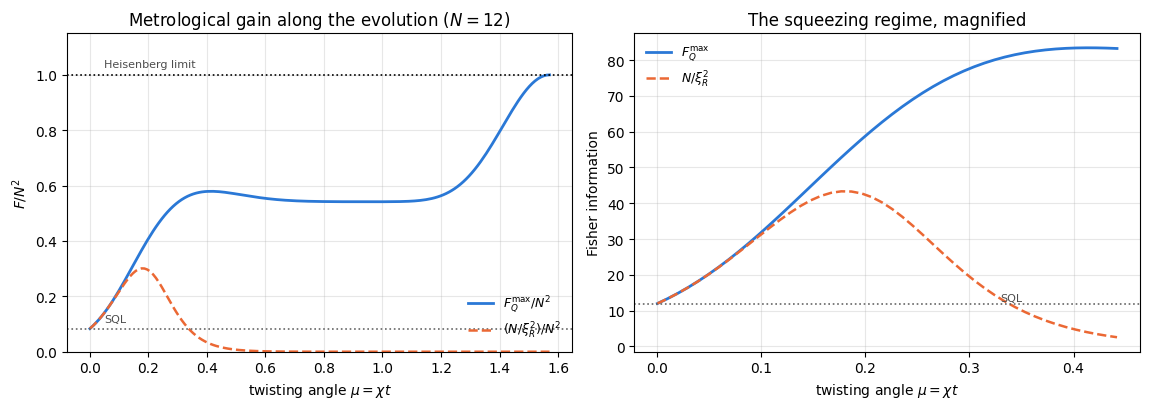

In [20]:
# ==============================================================================
# FIGURE: F_Q and N/xi_R^2 along the whole one-axis-twisting evolution
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))

axes[0].plot(MU_CMP, F_max / N_CMP ** 2, "-", color=PALETTE[0], lw=2.0, label=r"$F_Q^{\max}/N^2$")
axes[0].plot(MU_CMP, (N_CMP / xiR2) / N_CMP ** 2, "--", color=PALETTE[1], lw=1.8,
             label=r"$(N/\xi_R^2)/N^2$")
axes[0].axhline(1.0 / N_CMP, color="0.4", ls=":", lw=1.2)
axes[0].axhline(1.0, color="k", ls=":", lw=1.2)
axes[0].text(0.05, 1.03, "Heisenberg limit", fontsize=8, color="0.3")
axes[0].text(0.05, 1.3 / N_CMP, "SQL", fontsize=8, color="0.3")
axes[0].set_xlabel(r"twisting angle $\mu=\chi t$"); axes[0].set_ylabel(r"$F/N^2$")
axes[0].set_ylim(0, 1.15)
axes[0].set_title(f"Metrological gain along the evolution ($N={N_CMP}$)"); axes[0].legend(fontsize=9)

sel = MU_CMP < 0.45
axes[1].plot(MU_CMP[sel], F_max[sel], "-", color=PALETTE[0], lw=2.0, label=r"$F_Q^{\max}$")
axes[1].plot(MU_CMP[sel], (N_CMP / xiR2)[sel], "--", color=PALETTE[1], lw=1.8, label=r"$N/\xi_R^2$")
axes[1].axhline(N_CMP, color="0.4", ls=":", lw=1.2); axes[1].text(0.33, N_CMP * 1.05, "SQL", fontsize=8, color="0.3")
axes[1].set_xlabel(r"twisting angle $\mu=\chi t$"); axes[1].set_ylabel("Fisher information")
axes[1].set_title("The squeezing regime, magnified"); axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

Equation (26) holds at every twisting angle, and the two curves separate early.

* At $\mu=0$ both equal $N=12$: a coherent spin state is exactly at the standard quantum limit and the quadrature
  readout is optimal for it. (The top eigenvalue is then doubly degenerate, $\mathcal F_{yy}=\mathcal F_{zz}=N$, so the
  printed direction $\hat y$ is one arbitrary choice in the $y$–$z$ plane.)
* For $\mu\ll\mu_{\rm opt}$ they track each other closely. At $\mu=0.039$ we measure $F_Q=18.243$ against
  $N/\xi_R^2=18.235$, a ratio of $1.0004$; at $\mu=0.079$ the ratio is $1.007$. In this early window $\xi_R^2$ is
  an accurate measure of the metrological gain.
* The ratio is $1.04$ at $\mu=0.118$, and $1.355$ at $\mu=0.196$, just past the optimum $\mu_{\rm opt}=0.180$:
  at the point where squeezing is best, $F_Q$ already exceeds $N/\xi_R^2$ by $35\%$, and by Eq. (26a) and the
  asymptotics of Section 10 the ratio tends to $3/2$ for large $N$. At $\mu=0.39$ the ratio is $15.4$; beyond
  that the contrast $\vert\langle\mathbf J\rangle\vert$ collapses, $\xi_R^2$ diverges, and the bound becomes vacuous
  while $F_Q$ keeps growing. Eq. (26a) is confirmed to machine precision at every angle where the optimal direction is
  transverse.
* $F_Q^{\max}/N^2$ rises to $0.58$ near $\mu=0.39$ and then settles on a broad plateau between $0.54$ and $0.56$ over
  most of the evolution, close to the value $\tfrac12+\tfrac1{2N}=0.542$ derived in
  [34](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb), and then climbs to exactly $1$
  at $\mu=\pi/2$: the Heisenberg limit, reached by the cat state whose two lobes we saw in the Husimi maps. The optimal
  generator direction, read off the eigenvector, starts at $45^\circ$ between $\hat y$ and $\hat z$ (it is the
  anti-squeezed axis, perpendicular to the squeezed one of Section 5), turns towards $\hat y$ as the ellipse shears
  ($0.77\,\hat y+0.64\,\hat z$ at $\mu=0.039$, $0.95\,\hat y+0.31\,\hat z$ at $\mu=0.39$), and ends exactly on $\hat x$,
  the axis joining the two lobes.

So the useful entanglement keeps growing long after the squeezing parameter has given up. Extracting it requires a
different readout than "measure one quadrature and invert the mean" — and that is what
[34 — from one-axis twisting to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb)
does: it follows the same evolution to $\mu=\pi/2$, identifies the cat and its axis, encodes the phase with the optimal
generator, reads out the parity, and reaches $F_Q=N^2$ — and then asks what noise does to all of it.

## 14. Key takeaways

* A coherent spin state has an **isotropic** transverse projection noise $\mathrm{Var}(J_\perp)=N/4$, giving the
  standard quantum limit $\Delta\phi=1/\sqrt{NM}$. Squeezing redistributes that noise between two conjugate
  quadratures; the uncertainty relation forbids reducing both.
* **One-axis twisting**, $H=\chi J_z^2$, equals $\tfrac{\chi}{2}\sum_{i<j}Z_iZ_j$ up to a constant
  (Eq. (6): $\sum_{i<j}Z_iZ_j=2J_z^2-N/2$), and is realised by collisions in a condensate, by cavity feedback and by
  the Mølmer–Sørensen interaction in ion traps.
* The evolution is a rotation about $\hat z$ by the **operator-valued angle** $\simeq2\chi t J_z$: it *shears* the uncertainty
  disc. Because all $Z_iZ_j$ terms commute, the gate circuit and the diagonal phase multiplication are **exactly**
  equal — zero Trotter error, verified to $10^{-15}$ up to $\mu=3$.
* Two squeezing parameters: $\xi_S^2=4V_{\min}/N$ (noise reduction) and
  $\xi_R^2=NV_{\min}/\vert\langle\mathbf J\rangle\vert^2=\xi_S^2/\mathcal{C}^2$ (phase sensitivity). Only $\xi_R^2$
  answers the question a clock asks, and only $\xi_R^2<1$ is an entanglement criterion (Sørensen *et al.*, proved in
  Section 8.4); random product states reach $\xi_S^2$ far below $1$ while keeping $\xi_R^2>1$.
* The closed-form Kitagawa–Ueda results, Eqs. (17)–(23), reproduce the exact simulation to $3\times10^{-14}$. The
  optimum scales as $\mu_{\rm opt}\sim3^{1/6}N^{-2/3}$ and $\xi^2_{S,\min}\sim\tfrac12(3/N)^{2/3}$ — a law that only
  becomes visible above $N\approx10^2$: fitted over $6\le N\le20$ the exponents come out between $-0.54$ and $-0.69$,
  and the local slope of $\xi^2_{S,\min}$ settles on $-2/3$ only from $N\approx10^3$. The Wineland parameter has the same
  asymptotic law with a relative correction $(3/N)^{1/3}$, Eq. (24a), so its local slope is steeper than $-2/3$ (about
  $-0.73$ near $N=100$) and approaches it very slowly; a fit over a short range of $N$ measures an average of drifting
  local slopes.
* Simulated end to end at $N=10$ (twist, align, encode, sample bit strings, maximum likelihood), the squeezed
  interferometer reaches $\Delta\hat\phi=(0.50$–$0.54)/\sqrt{NM}$, around the $\sqrt{N/I}=0.507$ of its classical
  Fisher information and below the $\xi_R=0.557$ predicted by error propagation, because the likelihood uses the whole
  histogram rather than its mean ($I=38.98$ against $N/\xi_R^2=32.27$, both below $F_Q=39.61$). The estimator's bias
  vanishes at $\phi=0$ by symmetry; measured at $\phi=0.2$ it agrees with the first-order prediction $b_1/M$ at
  $M=100$.
* The Husimi-$Q$ maps show disc $\to$ tilted ellipse $\to$ S-shape $\to$ multi-lobed state $\to$ two-lobed cat at
  $\mu=\pi/2$. The spectrum $\chi m^2$ is integer-spaced, so the dynamics is exactly periodic and the "decoherence" at
  intermediate times is reversible.
* $F_Q\ge N/\xi_R^2$, and for twisted states the ratio of the two is exactly the excess of the transverse uncertainty
  product over its minimum, Eq. (26a). It is close to $1$ only for $\mu\ll\mu_{\rm opt}$, is $1.35$ just past the
  optimum for $N=12$ and tends to $3/2$ at the optimum for large $N$. Beyond the optimum the squeezing parameter stops measuring the
  metrological resource: at $\mu=\pi/2$ the state has $F_Q=N^2$ while $\xi_R^2=\infty$.

## 15. Exercises

1. **(★)** Verify Eq. (6) numerically: build the dense $\sum_{i<j}Z_iZ_j$ and $2J_z^2-N/2$ for $N=4$ with
   Kronecker products (`np.kron` of $Z$ and the identity, as in Section 4.2) and compare them entry by entry. Then check that `oat_circuit(psi, mu)` *without* the
   global phase $e^{-i\mu N/4}$ still gives the same expectation values.
2. **(★)** Plot $\mathcal{C}(\mu)=\cos^{N-1}\mu$ and $\xi_S^2(\mu)$ on the same axes for $N=20$ and read off the
   twisting angle at which the contrast has fallen to $1/e$. Compare it with $\mu_{\rm opt}$.
3. **(★★)** Two-axis counter-twisting. Replace $H=\chi J_z^2$ by $H=\tfrac{\chi}{2i}(J_+^2-J_-^2)=\chi(J_xJ_y+J_yJ_x)$
   with $J_\pm=J_x\pm iJ_y$, and start from $\vert0\rangle^{\otimes N}$, the coherent state along $+\hat z$, which is the
   stationary point of this Hamiltonian (from $\vert+x\rangle^{\otimes N}$ the mean spin is rotated away and little
   squeezing results). The Hamiltonian is not diagonal in the computational basis; since it is built from collective
   operators and the initial state is permutation symmetric, it suffices to work in the $(N+1)$-dimensional symmetric
   subspace, with $J_x,J_y,J_z$ the standard spin-$N/2$ matrices, and to evolve with `expm`. Measure the best $\xi_S^2$
   for $N$ from $6$ to a few hundred. Fit a power law over $6\le N\le10$ first, then compute the local slopes
   $\mathrm d\ln\xi^2_{S,\min}/\mathrm d\ln N$ over the whole range. Over $N\le10$ the fitted exponent cannot be told
   apart from the one-axis-twisting value $-2/3$; the local slopes keep falling and reach about $-0.99$ between $N=160$
   and $N=320$, approaching the $1/N$ law of counter-twisting (Kitagawa and Ueda 1993) only at large $N$.
4. **(★★)** *Extend the code.* Add inhomogeneous couplings: replace the uniform $\chi$ in `oat_circuit` by a matrix
   $\chi_{ij}$ drawn from a distribution with mean $\chi$ and relative width $\sigma$. The gates still commute, so the
   evolution is still exact. Measure how $\xi_R^2$ at the optimum degrades with $\sigma$, averaging over several draws
   of $\chi_{ij}$.
5. **(★★)** Dephasing during the twisting. Using the density-tensor machinery of
   [07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb), split the evolution to $\mu$ into
   $n$ steps, each an OAT step of $\Delta\mu=\mu/n$ followed by the dephasing channel
   $\rho\to(1-p)\rho+pZ\rho Z$ on every qubit with $p=\gamma\,\Delta\mu$ ($\gamma$ is the dephasing rate in units of
   $\chi$). (a) Show that the two operations commute, so the splitting introduces no Trotter error and the result depends
   on $n$ only through $(1-2\gamma\Delta\mu)^n\to e^{-2\gamma\mu}$. (b) Using this, write $\langle J_x\rangle$, $C_{yy}$ and
   $C_{yz}$ of Section 9 with the factors $\eta=e^{-2\gamma\mu}$ and $\eta^2$ in the right places, and check them
   against the density-tensor simulation for $N=6$. (c) Expand $\xi_R^2$ to first order in $\mu$ and show that squeezing
   exists at short times only for $\gamma<(N-1)/4$. Confirm numerically for $N=6$ that the minimum of $\xi_R^2$ over
   $\mu$ reaches $1$ at $\gamma=1.25$.
6. **(★★)** *Physics.* Prove that $\langle J_z^2\rangle$ is constant under one-axis twisting for *any* initial state,
   and that $\langle J_z\rangle$ is too. Then explain why $\langle J_x\rangle$ can decay even though the evolution is
   unitary and the state remains pure.
7. **(★★★)** Optimal readout. For the squeezed state at the $\mu_{\rm opt}$ of $\xi_R^2$ and $N=8$, compute the quantum
   Fisher information $F_Q$ of the aligned state for the generator $J_z$ and compare it with the classical Fisher
   information of the population readout used in Section 11. Then build the SLD eigenbasis as in
   [30](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb) and check that its
   classical Fisher information equals $F_Q$. How much is the population readout losing at the optimum, and at
   $\mu=2\mu_{\rm opt}$ (re-computing the alignment angle there)?
8. **(★★★)** The echo protocol. A phase encoded with $J_z$ cannot be read out by an echo: $J_z$ commutes with
   $J_z^2$, so the inverse twisting simply undoes the preparation and the Fisher information returns to $N$. Encode
   instead with the optimal generator $\mathbf n_{\rm opt}(\mu)\cdot\mathbf J$ of Section 13, apply the inverse twisting
   $e^{+i\mu J_z^2}$, then a $\pi/2$ pulse about $\hat y$, and count the qubits in $\vert1\rangle$, i.e. measure $J_x$.
   Show numerically for $N=8$ that the classical Fisher information of this "interaction-based readout" at a small
   phase equals $F_Q^{\max}(\mu)$ at every twisting angle, including those where the population readout of Section 11
   has failed. (Echo protocols of this kind: Davis, Bentsen and Schleier-Smith 2016; Macrì, Smerzi and Pezzè 2016.)

## References

* M. Kitagawa and M. Ueda, *Squeezed spin states*, Physical Review A **47**, 5138 (1993).
* D. J. Wineland, J. J. Bollinger, W. M. Itano, F. L. Moore and D. J. Heinzen, *Spin squeezing and reduced quantum noise
  in spectroscopy*, Physical Review A **46**, R6797 (1992).
* D. J. Wineland, J. J. Bollinger, W. M. Itano and D. J. Heinzen, *Squeezed atomic states and projection noise in
  spectroscopy*, Physical Review A **50**, 67 (1994).
* A. Sørensen, L.-M. Duan, J. I. Cirac and P. Zoller, *Many-particle entanglement with Bose–Einstein condensates*,
  Nature **409**, 63 (2001).
* K. Mølmer and A. Sørensen, *Multiparticle entanglement of hot trapped ions*, Physical Review Letters **82**, 1835 (1999).
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*, Physical Review Letters **102**,
  100401 (2009).
* J. Ma, X. Wang, C. P. Sun and F. Nori, *Quantum spin squeezing*, Physics Reports **509**, 89 (2011).
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Reviews of Modern Physics **90**, 035005 (2018).
* C. Gross, T. Zibold, E. Nicklas, J. Estève and M. K. Oberthaler, *Nonlinear atom interferometer surpasses classical
  precision limit*, Nature **464**, 1165 (2010).
* M. F. Riedel, P. Böhi, Y. Li, T. W. Hänsch, A. Sinatra and P. Treutlein, *Atom-chip-based generation of entanglement
  for quantum metrology*, Nature **464**, 1170 (2010).
* I. D. Leroux, M. H. Schleier-Smith and V. Vuletić, *Implementation of cavity squeezing of a collective atomic spin*,
  Physical Review Letters **104**, 073602 (2010).
* D. Ulam-Orgikh and M. Kitagawa, *Spin squeezing and decoherence limit in Ramsey spectroscopy*, Physical Review A
  **64**, 052106 (2001).
* E. Davis, G. Bentsen and M. Schleier-Smith, *Approaching the Heisenberg limit without single-particle detection*,
  Physical Review Letters **116**, 053601 (2016).
* T. Macrì, A. Smerzi and L. Pezzè, *Loschmidt echo for quantum metrology*, Physical Review A **94**, 010102 (2016).

---
**About these lectures.** Written by Marcin Płodzień as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/